## Visualization Tutorial: Bulk Simulation (12 Datasets)

This visualization section focuses on **12 bulk_simulation datasets**:

- `BRCA_GSE114727`
- `CLL_GSE111014`
- `CRC_GSE139555`
- `ESCA_GSE173950`
- `HNSC_GSE103322`
- `LIHC_GSE140228`
- `LSCC_GSE150321`
- `NSCLC_GSE127471`
- `OV_GSE154600`
- `PAAD_GSE111672`
- `PBMC_30K`
- `SKCM_GSE123139`

The visualizations are designed to work with **cell-type fraction tables** (CSV).  
In each dataset, the **ground-truth fractions** are provided in the `input/` folder as:

- `input/{Dataset_name}_fraction.csv`

Predicted fractions can be obtained in **two ways** (described below).

---

### 1. Obtain Inputs

#### Option A: Download `BULK_simulation/` directly (recommended)

Download **`BULK_simulation/`** from **`XXXX`**.

It contains **12 datasets** (listed above).

---

### 2. Folder Structure (per dataset)

Each dataset folder `${DATASET_NAME}/` contains:

#### `input/`
- **Single-cell reference** (`sc`, `.h5ad`):  
  - `${DATASET_NAME}.h5ad`
- **Bulk data** (`bulk`, `.h5ad`):  
  - `${DATASET_NAME}_bulk.h5ad`
- **Ground-truth fractions** (`.csv`):  
  - `${DATASET_NAME}_fraction.csv`

#### `model/`
Pretrained checkpoints and batch effected results (provided for **reproducibility**), including:
- `batch_effect/{DATASET_NAME}_batch_effected.txt`
- `eigh_cache.pt`
- `multi_graph_graphs.pkl`
- `multi_graph_model.pt`

#### `result_data/`
Reference results provided for **comparison/validation** (and can also be used directly for visualization).

---

### 3. Predicted Fraction Files (Two Ways)

Your visualization typically needs a **predicted** cell-type fraction table (rows = bulk samples, columns = cell types, values = fractions). You can obtain predictions in two ways:

#### Option 1: Use the provided prediction output (`result_data/`)
Use:

- `result_data/{Dataset_name}_CytoBulk.csv`

These CSVs can be used as **provided/reference predictions** for plotting and validation.

#### Option 2: Generate predictions by running CytoBulk
To reproduce predictions yourself, follow the examples in:

- `conda_run_case/`
- `docker_run_case/`

In particular, refer to:

- `bulk_deconv_12_simulation.md`

After running deconvolution, the output will be saved under your specified `outdir`, typically as:

- `outdir/output/{Dataset_name}_prediction_frac.csv`

Example:
- `outdir/output/CLL_GSE111014_prediction_frac.csv`

---

### 4. Summary of Key CSV Files for Visualization

For each dataset, you may visualize and/or compare:

- **Ground truth:** `input/{Dataset_name}_fraction.csv`
- **Prediction (provided):** `result_data/{Dataset_name}_CytoBulk.csv`
- **Prediction (generated):** `outdir/output/{Dataset_name}_prediction_frac.csv`

**The following content uses CLL_GSE111014 as an example; please change the dataset_name and file_path accordingly when using.**

SCATTER PLOT CORRELATION ANALYSIS - RMSE VISUALIZATION (NO MAPPING)
Dataset: CLL_GSE111014
Method: CytoBulk
True data: C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_simulation\CLL_GSE111014\input\CLL_GSE111014_fraction.csv
Prediction data: C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_simulation\CLL_GSE111014\result_data\CLL_GSE111014_CytoBulk.csv
Using 250 samples
Using 8 common cell types: ['B cells', 'T CD4 naive cells', 'T CD8 central memory cells', 'T CD8 effector cells', 'T CD8 effector memory cells', 'Macrophages M1', 'Tprolifs', 'pDC cells']


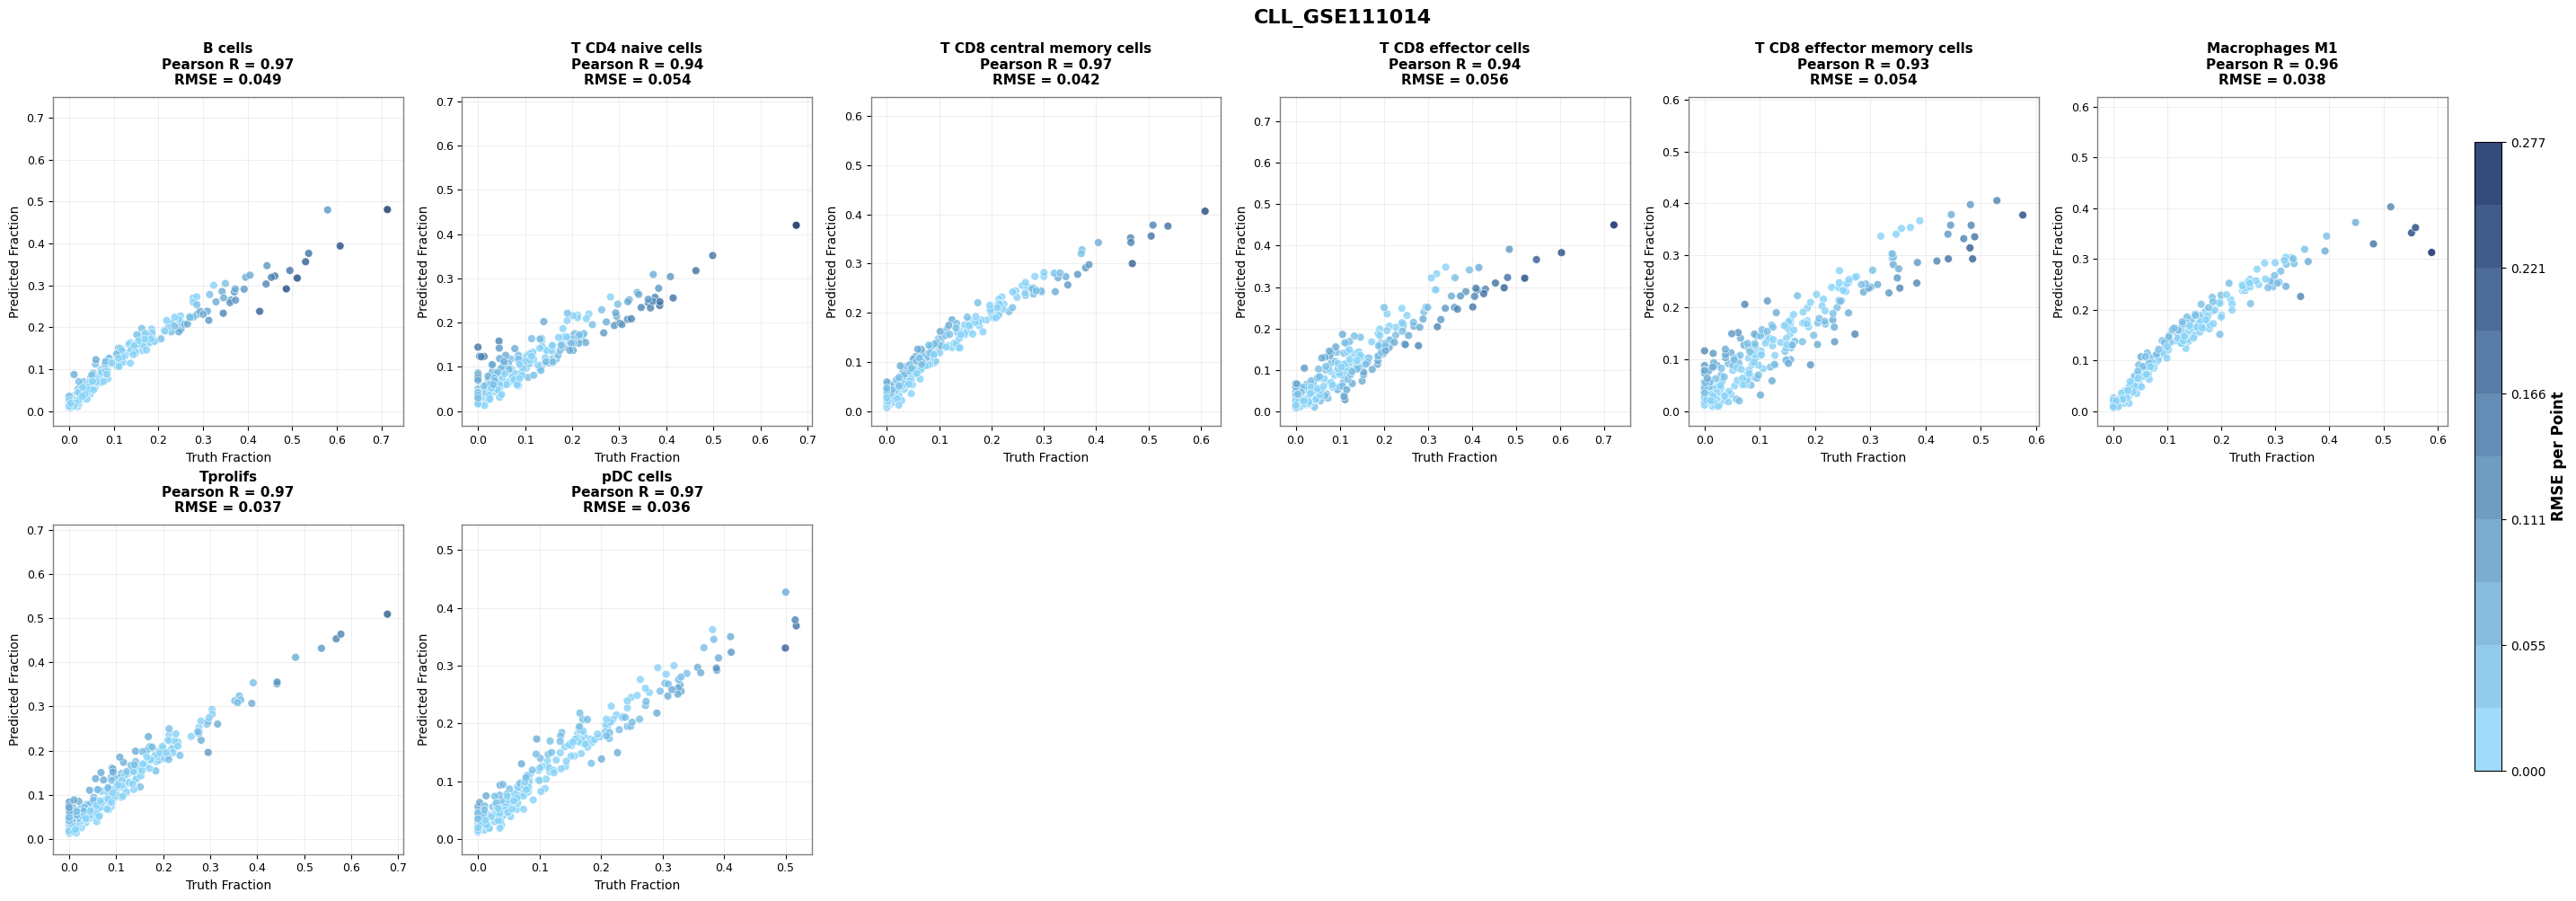

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# ==================== CONFIGURATION PARAMETERS ====================
DATASET_NAME = "CLL_GSE111014"
METHOD_NAME = "CytoBulk"

# Base dir (Zenodo downloaded BULK_simulation)
BASE_DIR = Path(r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_simulation") / DATASET_NAME

# Ground truth (input/)
TRUE_PATH = BASE_DIR / "input" / f"{DATASET_NAME}_fraction.csv"

# Prediction (provided/reference, result_data/)
PRED_PATH = BASE_DIR / "result_data" / f"{DATASET_NAME}_{METHOD_NAME}.csv"
# ==================================================================


def load_and_prepare_data(true_path, pred_path):
    """Load and prepare data (no mapping)."""
    true_path = Path(true_path)
    pred_path = Path(pred_path)

    if not true_path.exists():
        raise FileNotFoundError(f"True file not found: {true_path}")
    if not pred_path.exists():
        raise FileNotFoundError(f"Pred file not found: {pred_path}")

    true_data = pd.read_csv(true_path).fillna(0)
    pred_data = pd.read_csv(pred_path).fillna(0)

    true_data.columns = [c.strip() for c in true_data.columns]
    pred_data.columns = [c.strip() for c in pred_data.columns]

    # Basic checks
    if "sample_name" not in true_data.columns:
        raise ValueError(f"'sample_name' column not found in true file: {true_path}")
    if "sample_name" not in pred_data.columns:
        raise ValueError(f"'sample_name' column not found in pred file: {pred_path}")

    return true_data, pred_data


def calculate_jsd(true_values, pred_values):
    """Calculate Jensen-Shannon Divergence (optional metric)."""
    def normalize_to_prob(values):
        values = np.array(values, dtype=float)
        values = np.maximum(values, 1e-10)
        return values / np.sum(values)

    if np.var(true_values) == 0 or np.var(pred_values) == 0:
        return 0.0

    p = normalize_to_prob(true_values)
    q = normalize_to_prob(pred_values)
    m = 0.5 * (p + q)

    def kl_divergence(x, y):
        return np.sum(x * np.log(x / (y + 1e-10) + 1e-10))

    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)


def align_and_compute(true_data, pred_data):
    """
    No mapping: directly use intersection of cell-type columns (excluding sample_name/method).
    """
    true_sorted = true_data.sort_values("sample_name").reset_index(drop=True)
    pred_sorted = pred_data.sort_values("sample_name").reset_index(drop=True)

    # align samples by intersection
    if not true_sorted["sample_name"].equals(pred_sorted["sample_name"]):
        common = sorted(set(true_sorted["sample_name"]).intersection(set(pred_sorted["sample_name"])))
        true_sorted = true_sorted[true_sorted["sample_name"].isin(common)].sort_values("sample_name").reset_index(drop=True)
        pred_sorted = pred_sorted[pred_sorted["sample_name"].isin(common)].sort_values("sample_name").reset_index(drop=True)

    if len(true_sorted) == 0:
        raise ValueError("No common samples between true and pred tables.")

    # cell-type columns
    true_cell_cols = [c for c in true_sorted.columns if c != "sample_name"]
    pred_cell_cols = [c for c in pred_sorted.columns if c not in ["sample_name", "method"]]

    common_cells = [c for c in true_cell_cols if c in pred_cell_cols]
    if len(common_cells) == 0:
        raise ValueError(
            "No common cell-type columns between true and pred tables.\n"
            f"Example true cols: {true_cell_cols[:10]}\n"
            f"Example pred cols: {pred_cell_cols[:10]}"
        )

    print(f"Using {len(true_sorted)} samples")
    print(f"Using {len(common_cells)} common cell types: {common_cells}")

    correlations_data = {}
    for cell in common_cells:
        true_vals = true_sorted[cell].to_numpy(dtype=float)
        pred_vals = pred_sorted[cell].to_numpy(dtype=float)

        if np.var(true_vals) > 0 and np.var(pred_vals) > 0:
            corr, p_val = pearsonr(true_vals, pred_vals)
            jsd = calculate_jsd(true_vals, pred_vals)
            squared_error = (pred_vals - true_vals) ** 2
            overall_rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        else:
            corr, p_val, jsd = np.nan, np.nan, np.nan
            squared_error = (pred_vals - true_vals) ** 2
            overall_rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))

        correlations_data[cell] = {
            "true_values": true_vals,
            "pred_values": pred_vals,
            "correlation": corr,
            "p_value": p_val,
            "jsd": jsd,
            "squared_error": squared_error,
            "overall_rmse": overall_rmse,
        }

    return correlations_data, common_cells


def create_custom_colormap():
    """Create custom 10-level blue gradient colormap."""
    from matplotlib.colors import LinearSegmentedColormap

    light_color = "#87d3f8"
    dark_color = "#011f5b"
    return LinearSegmentedColormap.from_list("custom_blue_gradient", [light_color, dark_color], N=10)


def create_scatter_plot(correlations_data, dataset_name):
    valid_cells = list(correlations_data.keys())
    n_cells = len(valid_cells)

    n_cols = 6
    n_rows = (n_cells + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 5 * n_rows))
    fig.suptitle(f"{dataset_name}", fontsize=16, fontweight="bold", y=0.998)

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    cmap = create_custom_colormap()

    # unified color scale by point RMSE
    all_sq = np.concatenate([correlations_data[c]["squared_error"] for c in valid_cells])
    vmin = 0.0
    vmax = float(np.sqrt(np.max(all_sq))) if np.max(all_sq) > 0 else 1.0

    scatter = None
    for idx, cell in enumerate(valid_cells):
        r = idx // n_cols
        c = idx % n_cols
        ax = axes[r, c]

        d = correlations_data[cell]
        x = d["true_values"]
        y = d["pred_values"]
        point_err = np.sqrt(d["squared_error"])
        corr = d["correlation"]
        overall_rmse = d["overall_rmse"]

        scatter = ax.scatter(
            x, y,
            c=point_err,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            alpha=0.8, s=40,
            edgecolors="white", linewidth=0.5
        )

        corr_str = "NA" if np.isnan(corr) else f"{corr:.2f}"
        ax.set_title(f"{cell}\nPearson R = {corr_str}\nRMSE = {overall_rmse:.3f}",
                     fontsize=11, fontweight="bold", pad=10)
        ax.set_xlabel("Truth Fraction", fontsize=10)
        ax.set_ylabel("Predicted Fraction", fontsize=10)

        max_val = max(np.max(x), np.max(y))
        min_val = min(np.min(x), np.min(y))
        padding = (max_val - min_val) * 0.05 if max_val > min_val else 0.05
        ax.set_xlim(min_val - padding, max_val + padding)
        ax.set_ylim(min_val - padding, max_val + padding)

        ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
        ax.tick_params(labelsize=9)
        for spine in ax.spines.values():
            spine.set_linewidth(1)
            spine.set_color("gray")

    # turn off empty axes
    for idx in range(n_cells, n_rows * n_cols):
        r = idx // n_cols
        c = idx % n_cols
        axes[r, c].axis("off")

    # colorbar
    if scatter is not None:
        cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
        cbar = fig.colorbar(scatter, cax=cbar_ax)
        cbar.set_label("RMSE per Point", fontsize=12, fontweight="bold")
        cbar.ax.tick_params(labelsize=10)

        ticks = np.linspace(vmin, vmax, 6)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels([f"{t:.3f}" for t in ticks])

    plt.tight_layout()
    plt.subplots_adjust(right=0.91, top=0.9, hspace=0.3)
    return fig


def main():
    print("=" * 80)
    print("SCATTER PLOT CORRELATION ANALYSIS - RMSE VISUALIZATION (NO MAPPING)")
    print(f"Dataset: {DATASET_NAME}")
    print(f"Method: {METHOD_NAME}")
    print("=" * 80)
    print(f"True data: {TRUE_PATH}")
    print(f"Prediction data: {PRED_PATH}")

    true_data, pred_data = load_and_prepare_data(TRUE_PATH, PRED_PATH)
    correlations_data, common_cells = align_and_compute(true_data, pred_data)

    fig = create_scatter_plot(correlations_data, DATASET_NAME)
    plt.show()


if __name__ == "__main__":
    main()

## Visualization Tutorial: BULK_HGSOC

This visualization tutorial is for the **BULK_HGSOC** package.  
All visualizations are based on **cell-type fraction tables** (CSV) for simulated bulk samples.

CytoBulk results can be obtained in **two ways**:
1) use the provided CytoBulk output under `result_data/`, or  
2) generate your own CytoBulk predictions by running the deconvolution pipeline.

---

### 1) Download the `BULK_HGSOC` package

Download the folder **`BULK_HGSOC/`** from **`XXXX`**.

Folder structure (as provided):

- `BULK_HGSOC/`
  - `input/`
    - `GSM6720925.h5ad` (single-cell reference)
    - `simulated_bulk_adata.h5ad` (bulk / simulated bulk)
  - `model/` (pretrained checkpoints and batch effect result for reproduction)
  - `result_data/` (reference results for validation)

---

### 2) Files needed for visualization

#### Ground-truth (from `input/`)

Ground-truth cell-type fractions are provided in `input/` as:

- `input/simulated_bulk_proportions_random_500samples.csv`
- `input/simulated_bulk_proportions_specified_500samples.csv`

These files are used as **ground truth** for evaluation and visualization.

#### Other methods' results (from `result_data/`)

Results from other deconvolution methods are provided under:

- `result_data/`

These can be directly loaded for comparison plots.

#### CytoBulk predicted fractions (two ways)

**Option 1: Use the provided CytoBulk results**  
Use:

- `result_data/HGSOC_cytobulk_data.csv`

**Option 2: Generate CytoBulk results by running the pipeline**  
Follow the run instructions in:

- `bulk_deconv_HGSOC.md`

The generated CytoBulk prediction file will be saved under your specified output directory (`outdir`) (see `bulk_deconv_HGSOC.md` for the exact output path and filename).

---

### 3) Summary of key fraction tables (CSV)

For visualization and comparison, you may use:

- **Ground truth (random):** `input/simulated_bulk_proportions_random_500samples.csv`
- **Ground truth (specified):** `input/simulated_bulk_proportions_specified_500samples.csv`
- **CytoBulk (provided):** `result_data/HGSOC_cytobulk_data.csv`
- **CytoBulk (generated):** output produced by `bulk_deconv_HGSOC.md`
- **Other methods:** corresponding CSV files under `result_data/`

=== Cell Type Correlation, RMSE and JSD Box Plot Analysis (CytoBulk Priority) ===
Loading Ground Truth data...
  random: (500, 12)
  specified: (500, 12)

Loading prediction data...
  CytoBulk: (1000, 11)
  BayesPrism: (1000, 11)
  CIBERSORTx: (1000, 11)
  SCDC: (1000, 11)
  MuSiC: (1000, 11)
  Scaden: (1000, 11)

Calculating cell type correlations for random...
  CytoBulk: 11 valid cell types, mean correlation: 0.9458
  BayesPrism: 11 valid cell types, mean correlation: 0.9030
  CIBERSORTx: 11 valid cell types, mean correlation: 0.7925
  SCDC: 11 valid cell types, mean correlation: 0.5147
  MuSiC: 11 valid cell types, mean correlation: 0.5567
  Scaden: 11 valid cell types, mean correlation: 0.0959

Calculating cell type correlations for specified...
  CytoBulk: 11 valid cell types, mean correlation: 0.9194
  BayesPrism: 11 valid cell types, mean correlation: 0.7760
  CIBERSORTx: 11 valid cell types, mean correlation: 0.7376
  SCDC: 11 valid cell types, mean correlation: 0.4773
  MuSiC

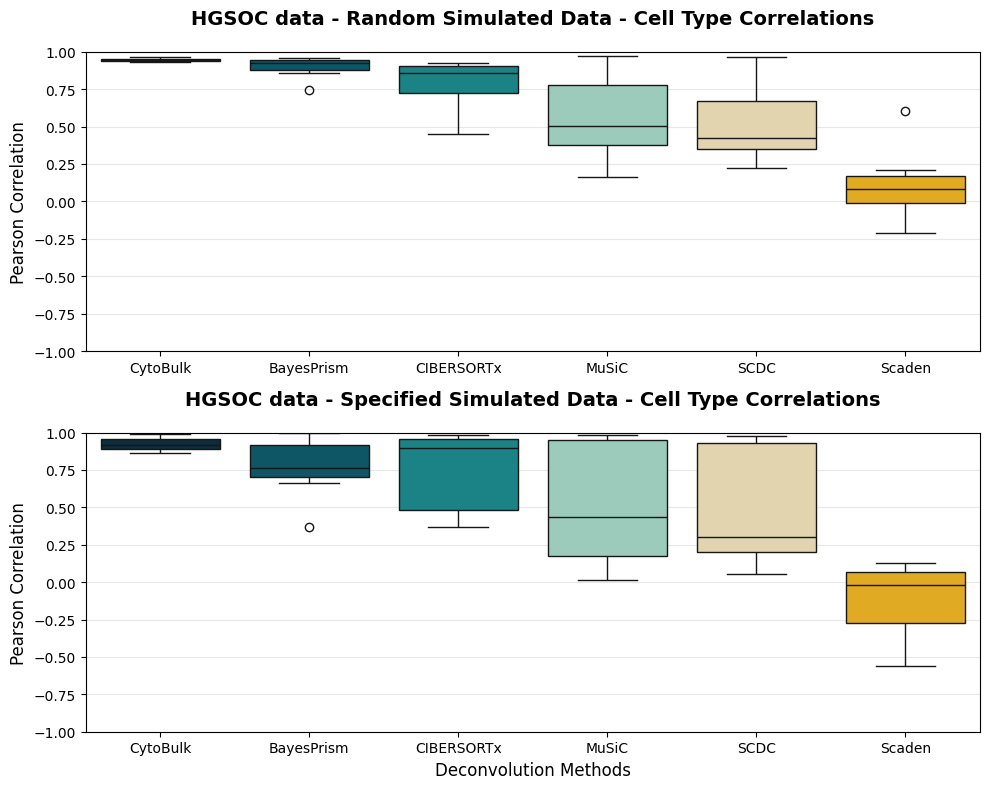


Plotting RMSE Box Plot...


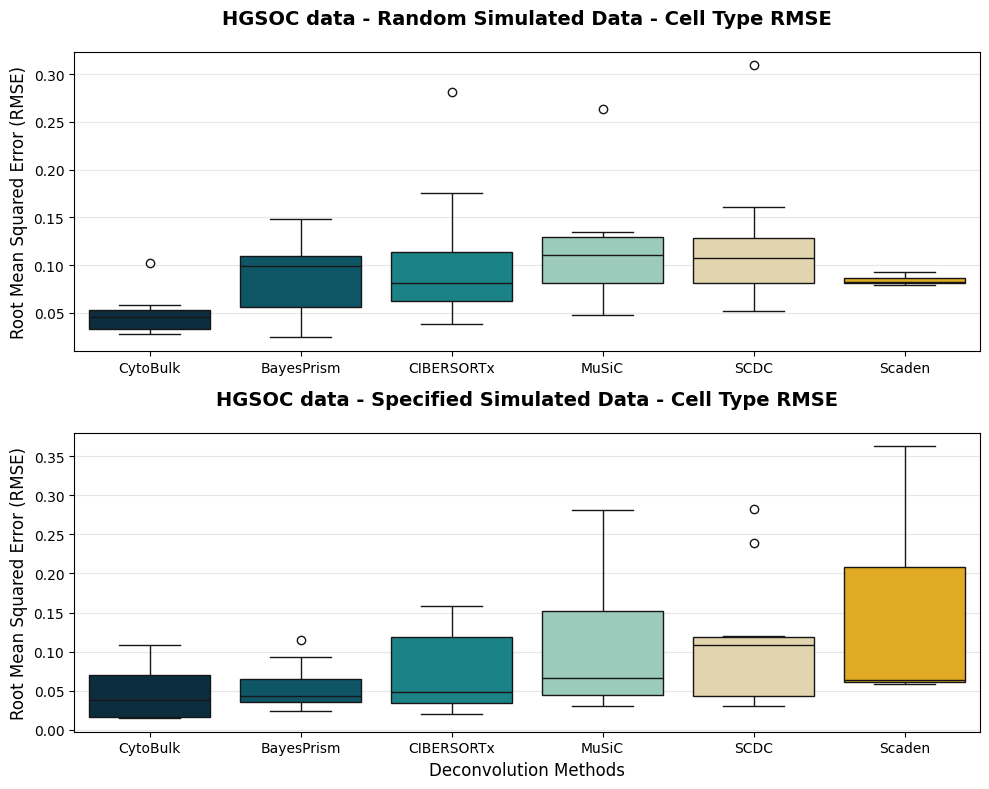


Plotting JSD Box Plot...


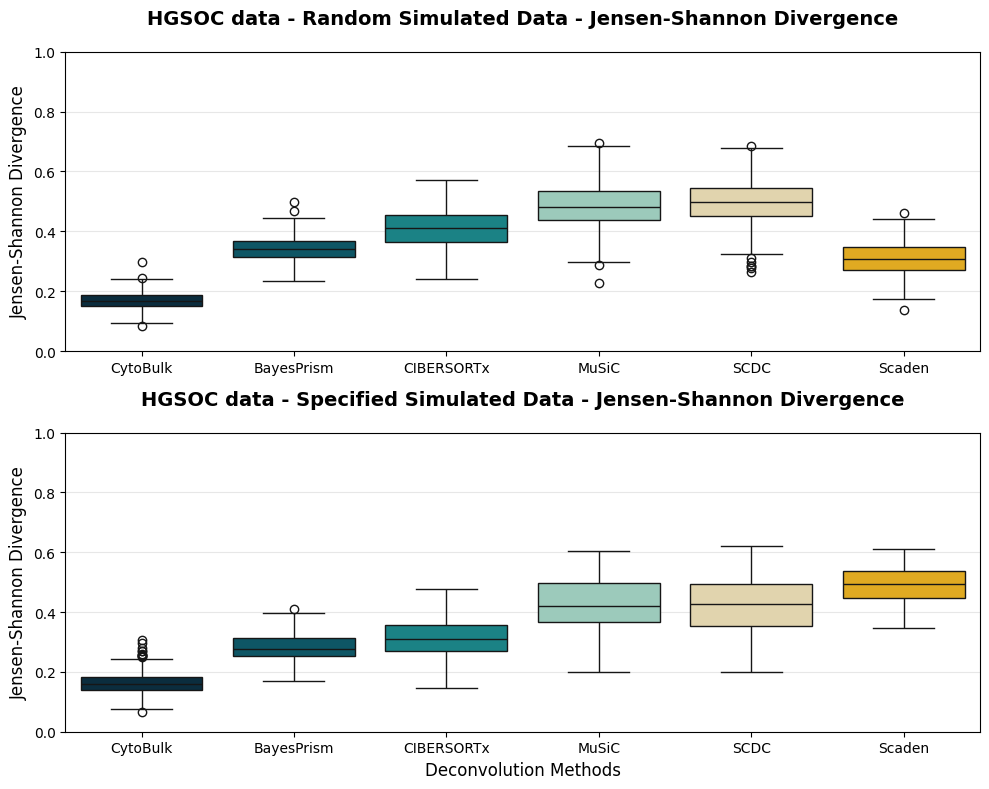

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')


def load_data():
    """Load all data files"""

    # Data file paths
    base_path = r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_HGSOC\result_data"

    # Ground truth files
    gt_files = {
        'random': r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_HGSOC\input\simulated_bulk_proportions_random_500samples.csv",
        'specified': r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_HGSOC\input\simulated_bulk_proportions_specified_500samples.csv"
    }

    # Prediction method files - CytoBulk first
    pred_files = {
        'CytoBulk': f"{base_path}\\HGSOC_cytobulk_data.csv",
        'BayesPrism': f"{base_path}\\HGSOC_BayesPrism_data.csv",
        'CIBERSORTx': f"{base_path}\\HGSOC_CIBERSORTx_data.csv",
        'SCDC': f"{base_path}\\HGSOC_SCDC_data.csv",
        'MuSiC': f"{base_path}\\HGSOC_music_data.csv",
        'Scaden': f"{base_path}\\HGSOC_scaden_data.csv",
    }

    gt_data = {}
    pred_data = {}

    print("Loading Ground Truth data...")
    for name, file_path in gt_files.items():
        try:
            df = pd.read_csv(file_path, index_col=0)
            gt_data[name] = df
            print(f"  {name}: {df.shape}")
        except Exception as e:
            print(f"  Error loading {name}: {e}")

    print("\nLoading prediction data...")
    for name, file_path in pred_files.items():
        try:
            df = pd.read_csv(file_path, index_col=0)
            print(f"  {name}: {df.shape}")
            pred_data[name] = df
        except Exception as e:
            print(f"  Error loading {name}: {e}")

    return gt_data, pred_data


def calculate_celltype_correlations(gt_data, pred_data):
    """Calculate Pearson correlation coefficient for each cell type"""
    results = {}

    for gt_type in gt_data.keys():
        gt_df = gt_data[gt_type]
        results[gt_type] = {}

        print(f"\nCalculating cell type correlations for {gt_type}...")

        for method_name in pred_data.keys():
            pred_df = pred_data[method_name]

            common_samples = gt_df.index.intersection(pred_df.index)
            common_celltypes = gt_df.columns.intersection(pred_df.columns)

            if len(common_samples) == 0 or len(common_celltypes) == 0:
                print(f"  {method_name}: No common samples or cell types")
                results[gt_type][method_name] = {}
                continue

            gt_common = gt_df.loc[common_samples, common_celltypes]
            pred_common = pred_df.loc[common_samples, common_celltypes]

            celltype_correlations = {}
            for celltype in common_celltypes:
                gt_values = gt_common[celltype].values
                pred_values = pred_common[celltype].values

                mask = ~(np.isnan(gt_values) | np.isnan(pred_values))
                if np.sum(mask) < 3:
                    celltype_correlations[celltype] = np.nan
                    continue

                corr, _ = pearsonr(gt_values[mask], pred_values[mask])
                celltype_correlations[celltype] = corr

            results[gt_type][method_name] = celltype_correlations

            valid_corrs = [v for v in celltype_correlations.values() if not np.isnan(v)]
            if valid_corrs:
                print(f"  {method_name}: {len(valid_corrs)} valid cell types, mean correlation: {np.mean(valid_corrs):.4f}")
            else:
                print(f"  {method_name}: No valid correlations")

    return results


def calculate_celltype_rmse(gt_data, pred_data):
    """Calculate RMSE for each cell type"""
    results = {}

    for gt_type in gt_data.keys():
        gt_df = gt_data[gt_type]
        results[gt_type] = {}

        print(f"\nCalculating cell type RMSE for {gt_type}...")

        for method_name in pred_data.keys():
            pred_df = pred_data[method_name]

            common_samples = gt_df.index.intersection(pred_df.index)
            common_celltypes = gt_df.columns.intersection(pred_df.columns)

            if len(common_samples) == 0 or len(common_celltypes) == 0:
                print(f"  {method_name}: No common samples or cell types")
                results[gt_type][method_name] = {}
                continue

            gt_common = gt_df.loc[common_samples, common_celltypes]
            pred_common = pred_df.loc[common_samples, common_celltypes]

            celltype_rmse = {}
            for celltype in common_celltypes:
                gt_values = gt_common[celltype].values
                pred_values = pred_common[celltype].values

                mask = ~(np.isnan(gt_values) | np.isnan(pred_values))
                if np.sum(mask) < 3:
                    celltype_rmse[celltype] = np.nan
                    continue

                mse = mean_squared_error(gt_values[mask], pred_values[mask])
                rmse = np.sqrt(mse)
                celltype_rmse[celltype] = rmse

            results[gt_type][method_name] = celltype_rmse

            valid_rmse = [v for v in celltype_rmse.values() if not np.isnan(v)]
            if valid_rmse:
                print(f"  {method_name}: {len(valid_rmse)} valid cell types, mean RMSE: {np.mean(valid_rmse):.6f}")
            else:
                print(f"  {method_name}: No valid RMSE")

    return results


def calculate_sample_jsd(gt_data, pred_data):
    """Calculate Jensen-Shannon divergence for each sample"""
    results = {}

    for gt_type in gt_data.keys():
        gt_df = gt_data[gt_type]
        results[gt_type] = {}

        print(f"\nCalculating sample JSD for {gt_type}...")

        for method_name in pred_data.keys():
            pred_df = pred_data[method_name]

            common_samples = gt_df.index.intersection(pred_df.index)
            common_celltypes = gt_df.columns.intersection(pred_df.columns)

            if len(common_samples) == 0 or len(common_celltypes) == 0:
                print(f"  {method_name}: No common samples or cell types")
                results[gt_type][method_name] = []
                continue

            gt_common = gt_df.loc[common_samples, common_celltypes]
            pred_common = pred_df.loc[common_samples, common_celltypes]

            sample_jsd = []
            for sample in common_samples:
                gt_props = gt_common.loc[sample].values
                pred_props = pred_common.loc[sample].values

                if np.any(np.isnan(gt_props)) or np.any(np.isnan(pred_props)):
                    continue

                gt_props = np.maximum(gt_props, 0)
                pred_props = np.maximum(pred_props, 0)

                gt_sum = np.sum(gt_props)
                pred_sum = np.sum(pred_props)

                if gt_sum == 0 or pred_sum == 0:
                    continue

                gt_props = gt_props / gt_sum
                pred_props = pred_props / pred_sum

                jsd = jensenshannon(gt_props, pred_props)
                if not np.isnan(jsd):
                    sample_jsd.append(jsd)

            results[gt_type][method_name] = sample_jsd

            if sample_jsd:
                print(f"  {method_name}: {len(sample_jsd)} valid samples, mean JSD: {np.mean(sample_jsd):.6f}")
            else:
                print(f"  {method_name}: No valid JSD")

    return results


def prepare_boxplot_data(results, metric_name):
    """Prepare data for box plot"""
    plot_data = []

    for gt_type in results.keys():
        for method_name in results[gt_type].keys():

            if metric_name == 'JSD':
                metric_values = results[gt_type][method_name]
                for metric_value in metric_values:
                    if not np.isnan(metric_value):
                        plot_data.append({
                            'Ground_Truth': gt_type,
                            'Method': method_name,
                            metric_name: metric_value
                        })
            else:
                celltype_metrics = results[gt_type][method_name]
                for celltype, metric_value in celltype_metrics.items():
                    if not np.isnan(metric_value):
                        plot_data.append({
                            'Ground_Truth': gt_type,
                            'Method': method_name,
                            'Cell_Type': celltype,
                            metric_name: metric_value
                        })

    return pd.DataFrame(plot_data)


def plot_correlation_boxplot(plot_data, title_suffix=""):
    """Plot correlation box plot results (show only, no saving)"""
    plt.style.use('default')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    colors = ['#023047', '#005f73', '#0a9396', '#94d2bd', '#e9d8a6', '#ffb703', '#fb8500', '#fd9e02']
    method_order = ['CytoBulk', 'BayesPrism', 'CIBERSORTx', 'MuSiC', 'SCDC', 'Scaden']
    suffix = f" ({title_suffix})" if title_suffix else ""

    random_data = plot_data[plot_data['Ground_Truth'] == 'random']
    if not random_data.empty:
        available_methods = [m for m in method_order if m in random_data['Method'].unique()]
        sns.boxplot(
            data=random_data, x='Method', y='Pearson_Correlation',
            order=available_methods, palette=colors[:len(available_methods)], ax=ax1
        )
        ax1.set_title(f'HGSOC data - Random Simulated Data - Cell Type Correlations{suffix}',
                      fontsize=14, fontweight='bold', pad=20)
        ax1.set_ylabel('Pearson Correlation', fontsize=12)
        ax1.set_xlabel('')
        ax1.set_ylim(-1, 1)
        ax1.grid(axis='y', alpha=0.3)

    specified_data = plot_data[plot_data['Ground_Truth'] == 'specified']
    if not specified_data.empty:
        available_methods = [m for m in method_order if m in specified_data['Method'].unique()]
        sns.boxplot(
            data=specified_data, x='Method', y='Pearson_Correlation',
            order=available_methods, palette=colors[:len(available_methods)], ax=ax2
        )
        ax2.set_title(f'HGSOC data - Specified Simulated Data - Cell Type Correlations{suffix}',
                      fontsize=14, fontweight='bold', pad=20)
        ax2.set_ylabel('Pearson Correlation', fontsize=12)
        ax2.set_xlabel('Deconvolution Methods', fontsize=12)
        ax2.set_ylim(-1, 1)
        ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return fig


def plot_rmse_boxplot(plot_data, title_suffix=""):
    """Plot RMSE box plot results (show only, no saving)"""
    plt.style.use('default')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    colors = ['#023047', '#005f73', '#0a9396', '#94d2bd', '#e9d8a6', '#ffb703', '#fb8500', '#fd9e02']
    method_order = ['CytoBulk', 'BayesPrism', 'CIBERSORTx', 'MuSiC', 'SCDC', 'Scaden']
    suffix = f" ({title_suffix})" if title_suffix else ""

    random_data = plot_data[plot_data['Ground_Truth'] == 'random']
    if not random_data.empty:
        available_methods = [m for m in method_order if m in random_data['Method'].unique()]
        sns.boxplot(
            data=random_data, x='Method', y='RMSE',
            order=available_methods, palette=colors[:len(available_methods)], ax=ax1
        )
        ax1.set_title(f'HGSOC data - Random Simulated Data - Cell Type RMSE{suffix}',
                      fontsize=14, fontweight='bold', pad=20)
        ax1.set_ylabel('Root Mean Squared Error (RMSE)', fontsize=12)
        ax1.set_xlabel('')
        ax1.grid(axis='y', alpha=0.3)

    specified_data = plot_data[plot_data['Ground_Truth'] == 'specified']
    if not specified_data.empty:
        available_methods = [m for m in method_order if m in specified_data['Method'].unique()]
        sns.boxplot(
            data=specified_data, x='Method', y='RMSE',
            order=available_methods, palette=colors[:len(available_methods)], ax=ax2
        )
        ax2.set_title(f'HGSOC data - Specified Simulated Data - Cell Type RMSE{suffix}',
                      fontsize=14, fontweight='bold', pad=20)
        ax2.set_ylabel('Root Mean Squared Error (RMSE)', fontsize=12)
        ax2.set_xlabel('Deconvolution Methods', fontsize=12)
        ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return fig


def plot_jsd_boxplot(plot_data, title_suffix=""):
    """Plot JSD box plot results (show only, no saving)"""
    plt.style.use('default')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    colors = ['#023047', '#005f73', '#0a9396', '#94d2bd', '#e9d8a6', '#ffb703', '#fb8500', '#fd9e02']
    method_order = ['CytoBulk', 'BayesPrism', 'CIBERSORTx', 'MuSiC', 'SCDC', 'Scaden']
    suffix = f" ({title_suffix})" if title_suffix else ""

    random_data = plot_data[plot_data['Ground_Truth'] == 'random']
    if not random_data.empty:
        available_methods = [m for m in method_order if m in random_data['Method'].unique()]
        sns.boxplot(
            data=random_data, x='Method', y='JSD',
            order=available_methods, palette=colors[:len(available_methods)], ax=ax1
        )
        ax1.set_title(f'HGSOC data - Random Simulated Data - Jensen-Shannon Divergence{suffix}',
                      fontsize=14, fontweight='bold', pad=20)
        ax1.set_ylabel('Jensen-Shannon Divergence', fontsize=12)
        ax1.set_xlabel('')
        ax1.set_ylim(0, 1)
        ax1.grid(axis='y', alpha=0.3)

    specified_data = plot_data[plot_data['Ground_Truth'] == 'specified']
    if not specified_data.empty:
        available_methods = [m for m in method_order if m in specified_data['Method'].unique()]
        sns.boxplot(
            data=specified_data, x='Method', y='JSD',
            order=available_methods, palette=colors[:len(available_methods)], ax=ax2
        )
        ax2.set_title(f'HGSOC data - Specified Simulated Data - Jensen-Shannon Divergence{suffix}',
                      fontsize=14, fontweight='bold', pad=20)
        ax2.set_ylabel('Jensen-Shannon Divergence', fontsize=12)
        ax2.set_xlabel('Deconvolution Methods', fontsize=12)
        ax2.set_ylim(0, 1)
        ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return fig


def main(title_suffix=""):
    """Main function"""
    print("=== Cell Type Correlation, RMSE and JSD Box Plot Analysis (CytoBulk Priority) ===")

    gt_data, pred_data = load_data()
    if len(gt_data) == 0 or len(pred_data) == 0:
        print("Data loading failed")
        return

    correlation_results = calculate_celltype_correlations(gt_data, pred_data)
    rmse_results = calculate_celltype_rmse(gt_data, pred_data)
    jsd_results = calculate_sample_jsd(gt_data, pred_data)

    correlation_plot_data = prepare_boxplot_data(correlation_results, 'Pearson_Correlation')
    rmse_plot_data = prepare_boxplot_data(rmse_results, 'RMSE')
    jsd_plot_data = prepare_boxplot_data(jsd_results, 'JSD')

    if correlation_plot_data.empty and rmse_plot_data.empty and jsd_plot_data.empty:
        print("No valid data")
        return

    print(f"\nCorrelation data points: {len(correlation_plot_data)}")
    print(f"RMSE data points: {len(rmse_plot_data)}")
    print(f"JSD data points: {len(jsd_plot_data)}")

    if not correlation_plot_data.empty:
        methods = ['CytoBulk'] + sorted([m for m in correlation_plot_data['Method'].unique() if m != 'CytoBulk'])
        print(f"Included methods: {', '.join(methods)}")

    if not correlation_plot_data.empty:
        print("\nPlotting Correlation Box Plot...")
        plot_correlation_boxplot(correlation_plot_data, title_suffix)

    if not rmse_plot_data.empty:
        print("\nPlotting RMSE Box Plot...")
        plot_rmse_boxplot(rmse_plot_data, title_suffix)

    if not jsd_plot_data.empty:
        print("\nPlotting JSD Box Plot...")
        plot_jsd_boxplot(jsd_plot_data, title_suffix)


if __name__ == "__main__":
    main()

## Visualization Tutorial: BULK_Human_sc

This visualization tutorial is for the **BULK_Human_sc** package.  
All visualizations are based on **cell-type fraction tables** (CSV) for simulated bulk samples.

CytoBulk results can be obtained in **two ways**:
1) use the provided CytoBulk output under `result_data/`, or  
2) generate your own CytoBulk predictions by running the deconvolution pipeline.

---

### 1) Download the `BULK_Human_sc` package

Download the folder **`BULK_Human_sc/`** from **`XXXX`**.

Folder structure (as provided):

- `BULK_Human_sc/`
  - `input/`
    - `A36_sample.h5ad` (single-cell reference)
    - `simulated_bulk.h5ad` (bulk / simulated bulk)
  - `model/` (pretrained checkpoints for reproduction)
  - `result_data/` (reference results for validation)

> Note: this tutorial assumes `input/`, `model/`, and `result_data/` are directly under `BULK_Human_sc/`.

---

### 2) Files needed for visualization

#### Ground-truth (from `input/`)

Ground-truth cell-type fractions are provided in `input/` as:

- `input/ground_truth_proportions.csv`

This file is used as **ground truth** for evaluation and visualization.

#### Other methods' results (from `result_data/`)

Results from other deconvolution methods are provided under:

- `result_data/`

These outputs can be directly loaded for comparison plots (e.g., method-vs-ground-truth, method-vs-method).

#### CytoBulk predicted fractions (two ways)

**Option 1: Use the provided CytoBulk results**  
Use the CytoBulk result CSV shipped in `result_data/`, e.g.:

- `result_data/human_bulk_CytoBulk_data.csv`

**Option 2: Generate CytoBulk results by running the pipeline**  
Follow the run instructions in:

- `bulk_deconv_human_bulk.md`

The generated CytoBulk prediction file will be saved under your specified output directory (`outdir`) (see `bulk_deconv_human_bulk.md` for the exact output path and filename).

---

### 3) Summary of key fraction tables (CSV)

For visualization and comparison, you may use:

- **Ground truth:** `input/ground_truth_proportions.csv`
- **CytoBulk (provided):** `result_data/human_bulk_CytoBulk_data.csv`
- **CytoBulk (generated):** output produced by `bulk_deconv_human_bulk.md`
- **Other methods:** corresponding CSV files under `result_data/`

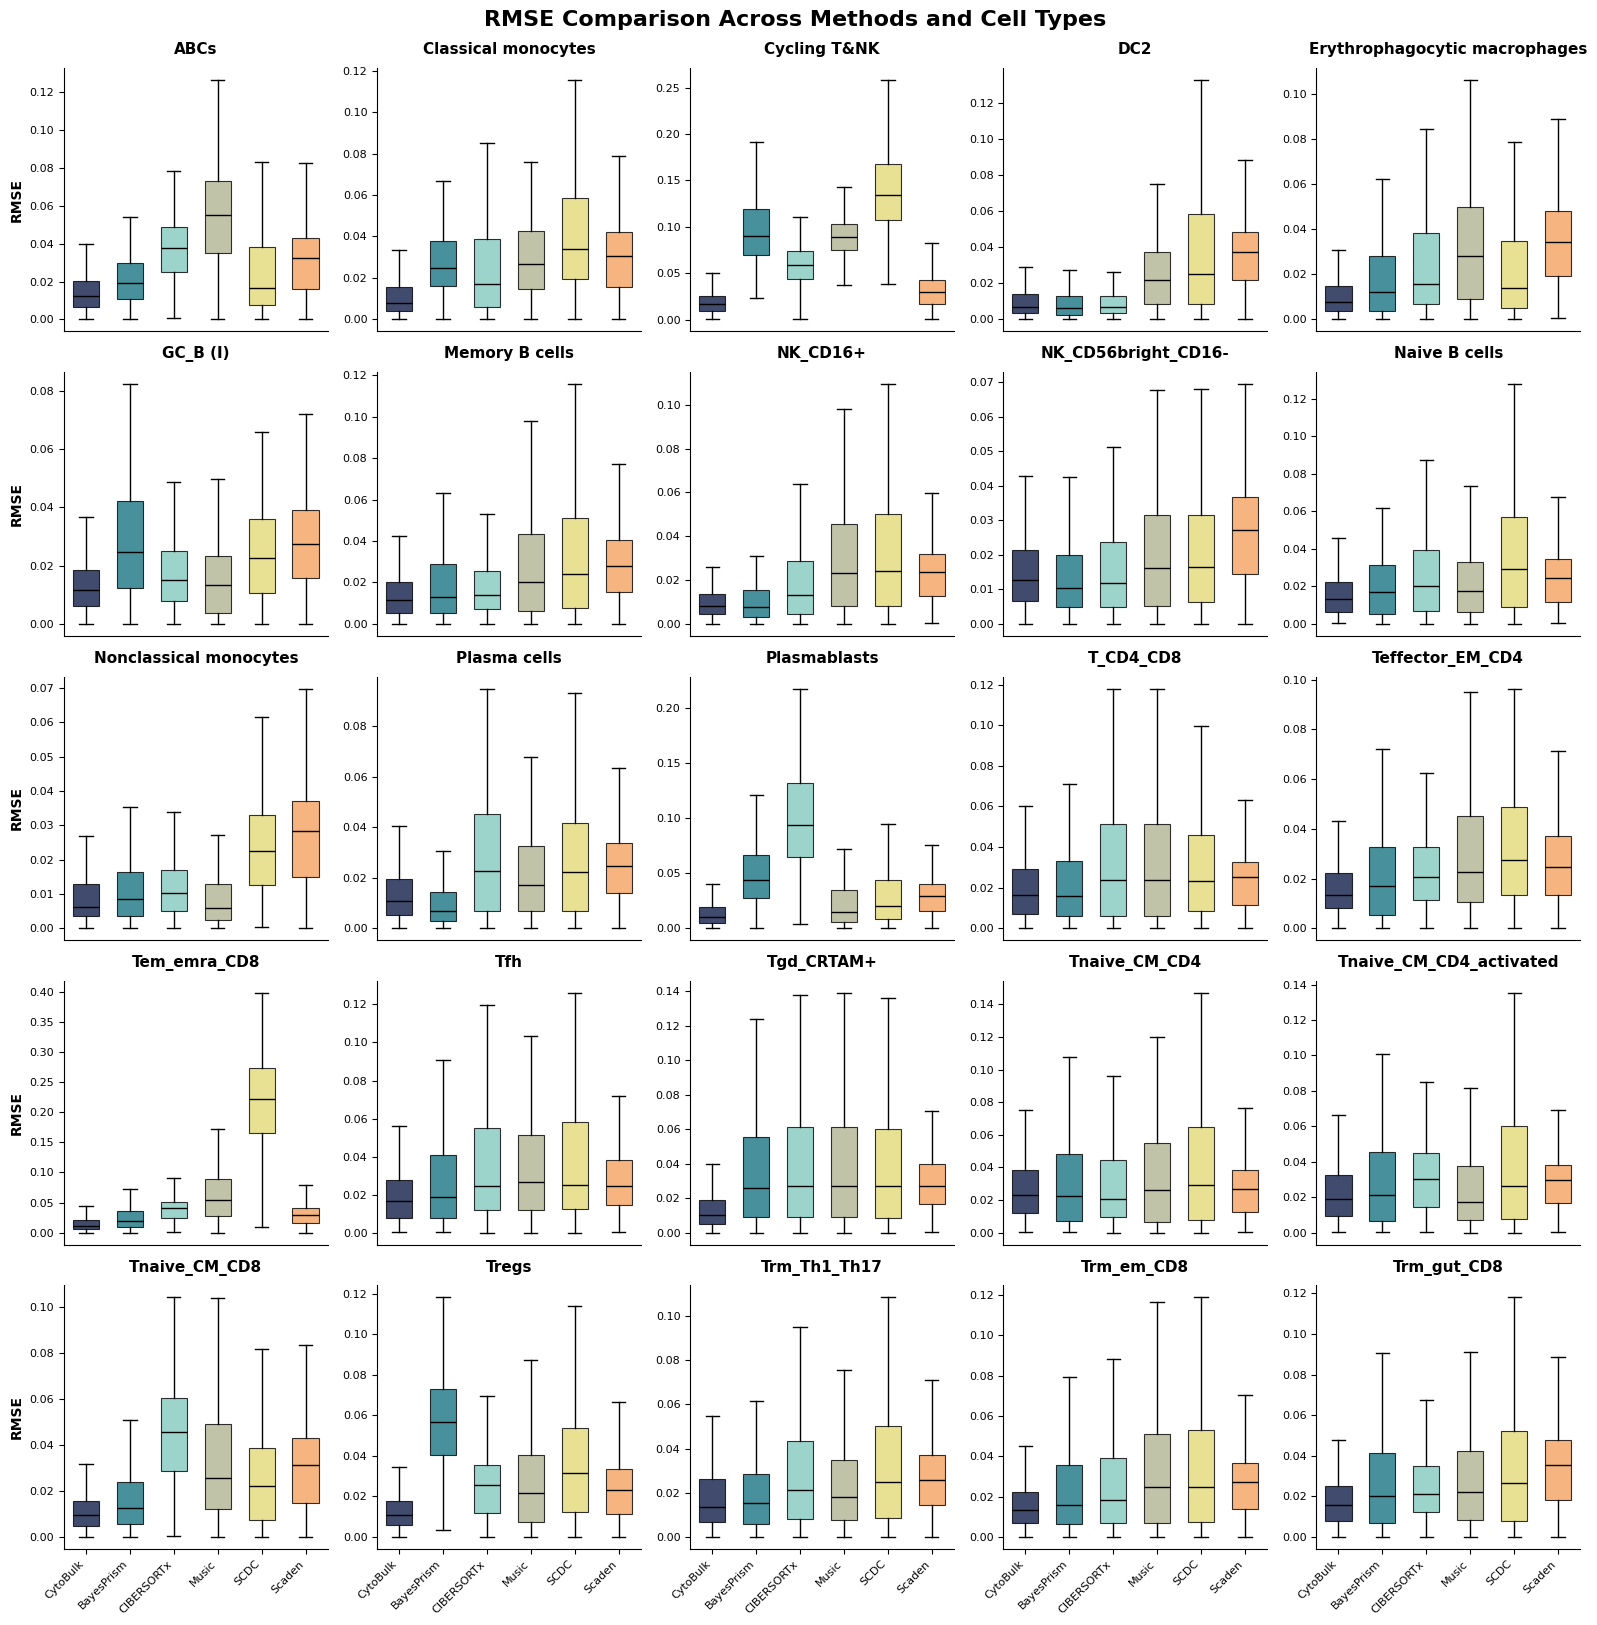

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Paths (define at the top)
# =========================
BASE_DIR = r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_Human_sc"
INPUT_DIR = os.path.join(BASE_DIR, "input")
RESULT_DIR = os.path.join(BASE_DIR, "result_data")

TRUE_FILE = os.path.join(INPUT_DIR, "ground_truth_proportions.csv")

PRED_FILES = {
    "BayesPrism": os.path.join(RESULT_DIR, "human_bulk_BayesPrism_data.csv"),
    "CIBERSORTx": os.path.join(RESULT_DIR, "human_bulk_CIBERSORTx_data.csv"),
    "CytoBulk": os.path.join(RESULT_DIR, "human_bulk_CytoBulk_data.csv"),
    "Music": os.path.join(RESULT_DIR, "human_bulk_Music_data.csv"),
    "Scaden": os.path.join(RESULT_DIR, "human_bulk_Scaden_data.csv"),
    "SCDC": os.path.join(RESULT_DIR, "human_bulk_SCDC_data.csv"),
}


def calculate_sample_wise_rmse(true_file, pred_files):
    """
    Calculate per-sample per-cell_type absolute error (named rmse in original code)
    after aligning common samples and cell types across all methods.
    """
    true_df = pd.read_csv(true_file, index_col=0)

    common_samples = set(true_df.index)
    common_cell_types = set(true_df.columns)

    pred_dfs = {}
    for method_name, pred_file in pred_files.items():
        pred_df = pd.read_csv(pred_file, index_col=0)
        pred_dfs[method_name] = pred_df
        common_samples &= set(pred_df.index)
        common_cell_types &= set(pred_df.columns)

    common_samples = sorted(common_samples)
    common_cell_types = sorted(common_cell_types)

    true_df_aligned = true_df.loc[common_samples, common_cell_types]

    all_rmse_data = []
    for method_name, pred_df in pred_dfs.items():
        pred_df_aligned = pred_df.loc[common_samples, common_cell_types]

        for sample in common_samples:
            true_row = true_df_aligned.loc[sample]
            pred_row = pred_df_aligned.loc[sample]

            for cell_type in common_cell_types:
                true_val = true_row[cell_type]
                pred_val = pred_row[cell_type]

                if not (np.isnan(true_val) or np.isnan(pred_val)):
                    all_rmse_data.append(
                        {
                            "sample": sample,
                            "cell_type": cell_type,
                            "method": method_name,
                            "rmse": abs(true_val - pred_val),
                        }
                    )

    return pd.DataFrame(all_rmse_data), common_cell_types


def create_rmse_comparison_plot(rmse_df, figsize=(16, 18), n_cols=5):
    """
    Create box plot grid for RMSE comparison (show only; no saving; no extra prints).
    """
    unique_cell_types = sorted(rmse_df["cell_type"].unique())
    n_cell_types = len(unique_cell_types)
    n_rows = int(np.ceil(n_cell_types / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    all_methods = sorted(rmse_df["method"].unique())
    methods = (["CytoBulk"] + [m for m in all_methods if m != "CytoBulk"]) if "CytoBulk" in all_methods else all_methods

    colors = ["#101e49", "#1a7683", "#84cabe", "#B1B493", "#e3da7a", "#f4a261", "#e76f51"]
    method_colors = {method: colors[i % len(colors)] for i, method in enumerate(methods)}

    for i, cell_type in enumerate(unique_cell_types):
        ax = axes[i]
        current_row = i // n_cols
        current_col = i % n_cols

        cell_data = rmse_df[rmse_df["cell_type"] == cell_type]
        if cell_data.empty:
            ax.set_visible(False)
            continue

        box_data, labels, colors_list = [], [], []
        for method in methods:
            method_data = cell_data[cell_data["method"] == method]["rmse"]
            if len(method_data) > 0:
                box_data.append(method_data.values)
                labels.append(method)
                colors_list.append(method_colors[method])

        if box_data:
            bp = ax.boxplot(
                box_data,
                labels=labels,
                patch_artist=True,
                widths=0.6,
                showfliers=False,
            )

            for patch, color in zip(bp["boxes"], colors_list):
                patch.set_facecolor(color)
                patch.set_alpha(0.8)
                patch.set_edgecolor("black")
                patch.set_linewidth(0.8)

            for element in ["whiskers", "medians", "caps"]:
                plt.setp(bp[element], color="black", linewidth=1)

        ax.set_title(cell_type, fontsize=11, fontweight="bold", pad=10)

        if current_col == 0:
            ax.set_ylabel("RMSE", fontsize=10, fontweight="bold")
        else:
            ax.set_ylabel("")

        if current_row == n_rows - 1:
            ax.tick_params(axis="x", rotation=45, labelsize=8)
            ax.set_xticklabels(labels, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis="x", which="both", length=0)

        ax.tick_params(axis="y", labelsize=8)
        ax.grid(False)
        ax.set_facecolor("white")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("black")
        ax.spines["bottom"].set_color("black")
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

    for j in range(n_cell_types, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("RMSE Comparison Across Methods and Cell Types", fontsize=16, fontweight="bold", y=0.95)
    fig.patch.set_facecolor("white")
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])

    plt.show()
    return fig


def main(figsize=(16, 18), n_cols=5):
    rmse_df, _ = calculate_sample_wise_rmse(TRUE_FILE, PRED_FILES)
    fig = create_rmse_comparison_plot(rmse_df, figsize=figsize, n_cols=n_cols)
    return rmse_df, fig


if __name__ == "__main__":
    main(figsize=(16, 18), n_cols=5)

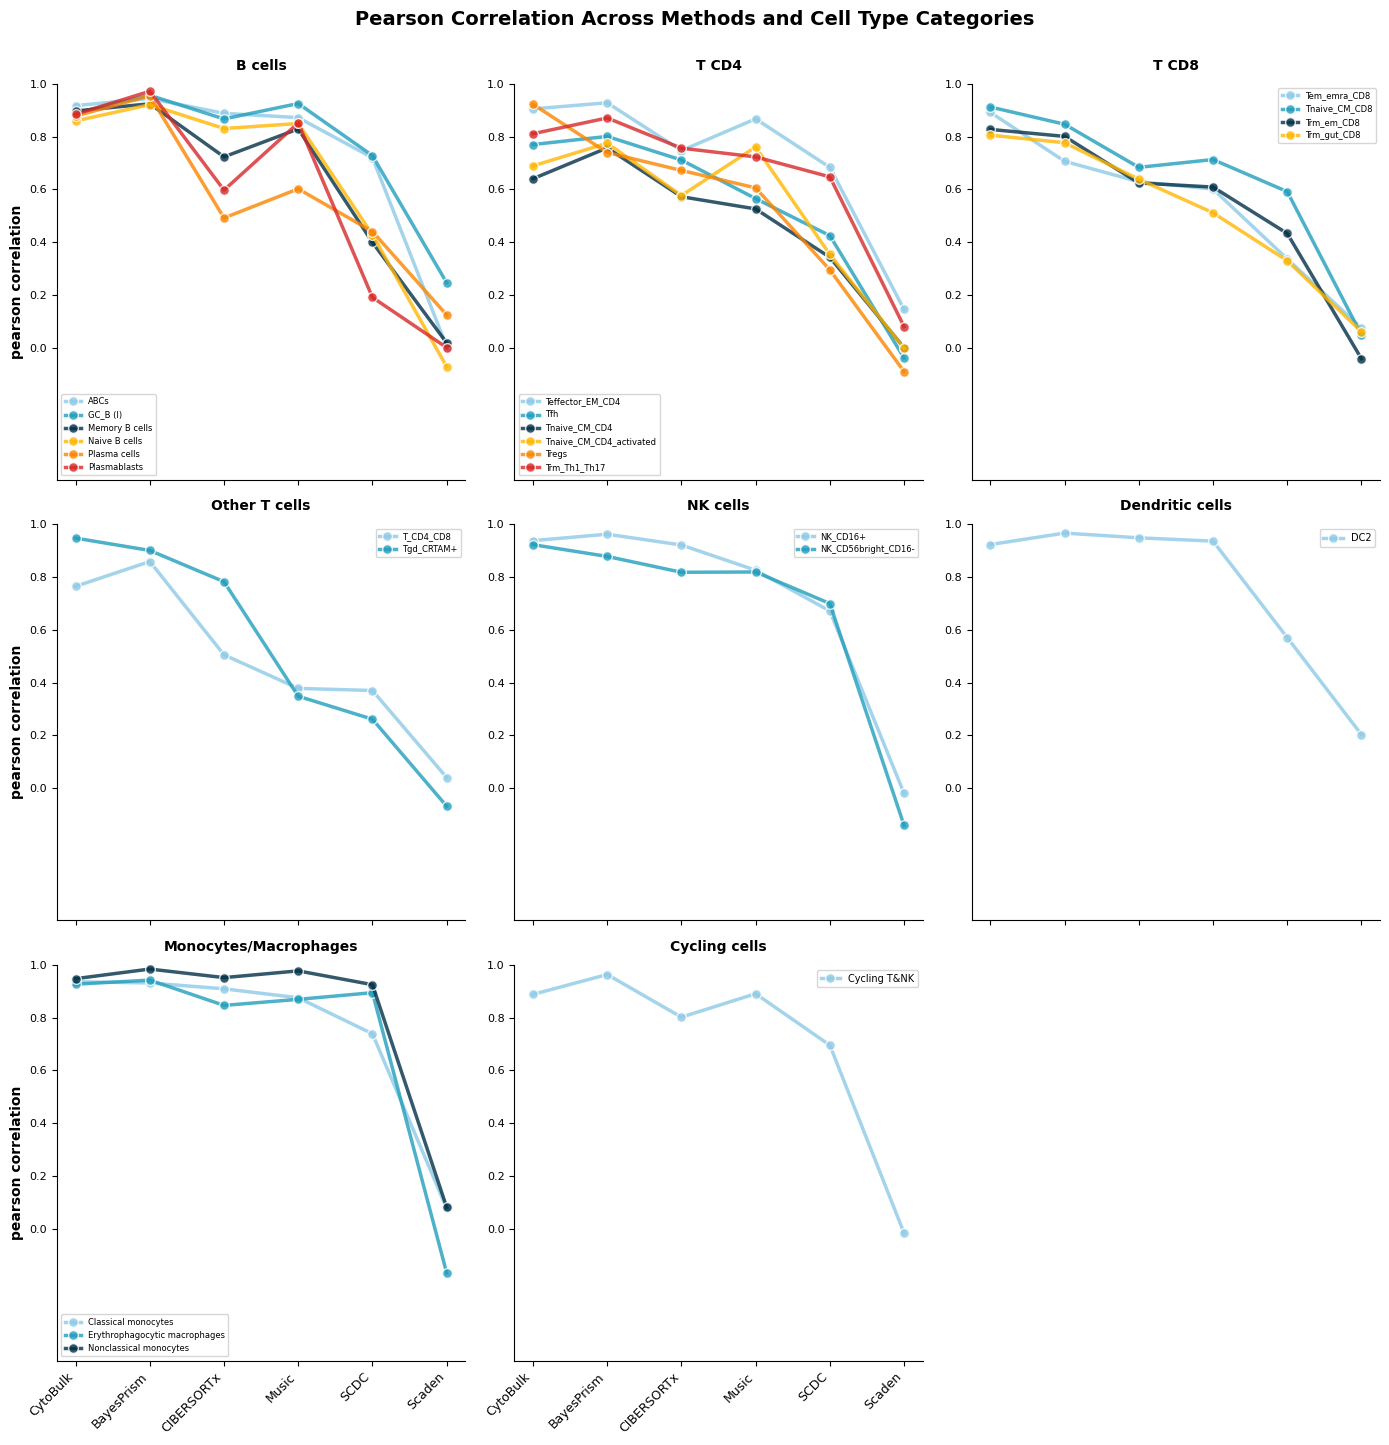

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# =========================
# Paths (define at the top)
# =========================
BASE_DIR = r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_Human_sc"
INPUT_DIR = os.path.join(BASE_DIR, "input")
OUTPUT_DIR = os.path.join(BASE_DIR, "result_data")

TRUE_FILE = os.path.join(INPUT_DIR, "ground_truth_proportions.csv")

PRED_FILES = {
    "BayesPrism": os.path.join(OUTPUT_DIR, "human_bulk_BayesPrism_data.csv"),
    "CIBERSORTx": os.path.join(OUTPUT_DIR, "human_bulk_CIBERSORTx_data.csv"),
    "CytoBulk": os.path.join(OUTPUT_DIR, "human_bulk_CytoBulk_data.csv"),
    "SCDC": os.path.join(OUTPUT_DIR, "human_bulk_SCDC_data.csv"),
    "Music": os.path.join(OUTPUT_DIR, "human_bulk_Music_data.csv"),
    "Scaden": os.path.join(OUTPUT_DIR, "human_bulk_Scaden_data.csv"),
}


def calculate_sample_wise_pearson(true_file, pred_files):
    """
    Calculate Pearson correlation coefficient for each cell type across samples,
    aligning common samples and cell types across all methods.
    """
    true_df = pd.read_csv(true_file, index_col=0)

    common_samples = set(true_df.index)
    common_cell_types = set(true_df.columns)

    # Determine common samples/cell types across all methods
    pred_dfs = {}
    for method_name, pred_file in pred_files.items():
        pred_df = pd.read_csv(pred_file, index_col=0)

        # Special handling for dwls - transpose
        if method_name.lower() == "dwls":
            pred_df = pred_df.T

        pred_dfs[method_name] = pred_df
        common_samples &= set(pred_df.index)
        common_cell_types &= set(pred_df.columns)

    common_samples = sorted(common_samples)
    common_cell_types = sorted(common_cell_types)

    true_df_aligned = true_df.loc[common_samples, common_cell_types]

    all_pearson_data = []
    for method_name, pred_df in pred_dfs.items():
        pred_df_aligned = pred_df.loc[common_samples, common_cell_types]

        for cell_type in common_cell_types:
            t = true_df_aligned[cell_type].values
            p = pred_df_aligned[cell_type].values

            valid = (~np.isnan(t)) & (~np.isnan(p))
            if valid.sum() < 2:
                continue

            t = t[valid]
            p = p[valid]

            if np.std(t) > 0 and np.std(p) > 0:
                corr, _ = pearsonr(t, p)
            else:
                corr = np.nan

            all_pearson_data.append(
                {
                    "cell_type": cell_type,
                    "method": method_name,
                    "pearson_correlation": corr,
                }
            )

    return pd.DataFrame(all_pearson_data), common_cell_types


def categorize_cell_types(pearson_df):
    """
    Categorize cell types based on their biological functions
    """
    categories = {
        "B cells": ["ABCs", "GC_B (I)", "Memory B cells", "Naive B cells", "Plasma cells", "Plasmablasts"],
        "T CD4": ["Teffector_EM_CD4", "Tfh", "Tnaive_CM_CD4", "Tnaive_CM_CD4_activated", "Tregs", "Trm_Th1_Th17"],
        "T CD8": ["Tem_emra_CD8", "Tnaive_CM_CD8", "Trm_em_CD8", "Trm_gut_CD8"],
        "Other T cells": ["T_CD4_CD8", "Tgd_CRTAM+"],
        "NK cells": ["NK_CD16+", "NK_CD56bright_CD16-"],
        "Dendritic cells": ["DC2"],
        "Monocytes/Macrophages": ["Classical monocytes", "Nonclassical monocytes", "Erythrophagocytic macrophages"],
        "Cycling cells": ["Cycling T&NK"],
    }

    def get_category(cell_name):
        for category, cell_list in categories.items():
            if cell_name in cell_list:
                return category
        return "Unclassified"

    pearson_df["category"] = pearson_df["cell_type"].apply(get_category)
    return pearson_df, categories


def create_pearson_line_plot(pearson_df, categories, figsize=(15, 10), n_cols=3):
    """
    Create line plot for Pearson correlation coefficients, one line per cell type.
    Only shows the plot (no saving).
    """
    all_methods = sorted(pearson_df["method"].unique())
    methods = (["CytoBulk"] + [m for m in all_methods if m != "CytoBulk"]) if "CytoBulk" in all_methods else all_methods

    cell_type_colors = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500", "#d62828"]

    available_categories = [c for c in categories.keys() if (pearson_df["category"] == c).any()]
    n_categories = len(available_categories)

    n_rows = int(np.ceil(n_categories / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for i, category in enumerate(available_categories):
        ax = axes[i]
        category_data = pearson_df[pearson_df["category"] == category]
        if category_data.empty:
            ax.set_visible(False)
            continue

        cell_types_in_category = sorted(category_data["cell_type"].unique())

        for j, cell_type in enumerate(cell_types_in_category):
            cell_data = category_data[category_data["cell_type"] == cell_type]

            x_positions, y_values = [], []
            for k, method in enumerate(methods):
                md = cell_data[cell_data["method"] == method]
                if not md.empty:
                    val = md["pearson_correlation"].iloc[0]
                    if not np.isnan(val):
                        x_positions.append(k)
                        y_values.append(val)

            if len(x_positions) >= 1:
                color = cell_type_colors[j % len(cell_type_colors)]
                ax.plot(
                    x_positions,
                    y_values,
                    color=color,
                    linestyle="-",
                    marker="o",
                    linewidth=2.5,
                    markersize=7,
                    alpha=0.8,
                    markeredgecolor="white",
                    markeredgewidth=1,
                    label=cell_type,
                )

        ax.set_title(category, fontsize=10, fontweight="bold", pad=10)

        if i % n_cols == 0:
            ax.set_ylabel("pearson correlation", fontsize=10, fontweight="bold")
        else:
            ax.set_ylabel("")

        current_row = i // n_cols
        if current_row == n_rows - 1:
            ax.set_xticks(range(len(methods)))
            ax.set_xticklabels(methods, rotation=45, ha="right", fontsize=9)
        else:
            ax.set_xticks(range(len(methods)))
            ax.set_xticklabels([])

        ax.set_ylim(-0.5, 1.0)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.tick_params(axis="y", labelsize=8)

        ax.grid(False)
        ax.set_facecolor("white")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("black")
        ax.spines["bottom"].set_color("black")
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

        if len(cell_types_in_category) >= 1:
            ax.legend(fontsize=6 if len(cell_types_in_category) > 1 else 7, frameon=True, loc="best", ncol=1)

    for i in range(n_categories, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(
        "Pearson Correlation Across Methods and Cell Type Categories",
        fontsize=14,
        fontweight="bold",
        y=0.95,
    )
    fig.patch.set_facecolor("white")
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    plt.show()
    return fig


def main(figsize=(14, 16), n_cols=3):
    pearson_df, _ = calculate_sample_wise_pearson(TRUE_FILE, PRED_FILES)
    pearson_df, categories = categorize_cell_types(pearson_df)
    fig = create_pearson_line_plot(pearson_df, categories, figsize=figsize, n_cols=n_cols)
    return pearson_df, fig


if __name__ == "__main__":
    main(figsize=(14, 16), n_cols=3)

### 4) Bulk mapping visualization

For **bulk mapping** visualization, you need **two inputs**:

1) **Marker genes list** (from `input/`):
- `input/marker_genes.csv`

2) **Bulk mapping result** (one of the following two ways):

- **Option 1: Use the provided mapping output**  
  - `result_data/bulk_data_human_bulk_mapping.h5ad`

- **Option 2: Generate the mapping output yourself**  
  Follow the pipeline in:
  - `bulk_deconv_human_bulk.md`  
  The generated mapping result (`.h5ad`) will be saved under your specified `outdir` (see the tutorial for the exact output path/name).

These two files (`marker_genes.csv` + mapping `.h5ad`) can then be used to produce bulk-mapping visualizations (e.g., marker-based highlighting and mapping-based annotation plots).

COSINE SIMILARITY ANALYSIS FOR TOP MARKER GENES

Loading data...
Loaded h5ad: 300 samples × 15004 genes
Loaded markers: 42410 gene-celltype pairs
Number of cell types: 25

FILTERING TOP MARKER GENES
After filtering score > 0: 23205 genes
  ABCs: 50 marker genes (top 50)
  Classical monocytes: 50 marker genes (top 50)
  Cycling T&NK: 50 marker genes (top 50)
  DC2: 50 marker genes (top 50)
  Erythrophagocytic macrophages: 50 marker genes (top 50)
  GC_B (I): 50 marker genes (top 50)
  Memory B cells: 50 marker genes (top 50)
  NK_CD16+: 50 marker genes (top 50)
  NK_CD56bright_CD16-: 50 marker genes (top 50)
  Naive B cells: 50 marker genes (top 50)
  Nonclassical monocytes: 50 marker genes (top 50)
  Plasma cells: 50 marker genes (top 50)
  Plasmablasts: 50 marker genes (top 50)
  T_CD4/CD8: 50 marker genes (top 50)
  Teffector/EM_CD4: 50 marker genes (top 50)
  Tem/emra_CD8: 50 marker genes (top 50)
  Tfh: 50 marker genes (top 50)
  Tgd_CRTAM+: 50 marker genes (top 50)
  Tnaive/CM_CD4

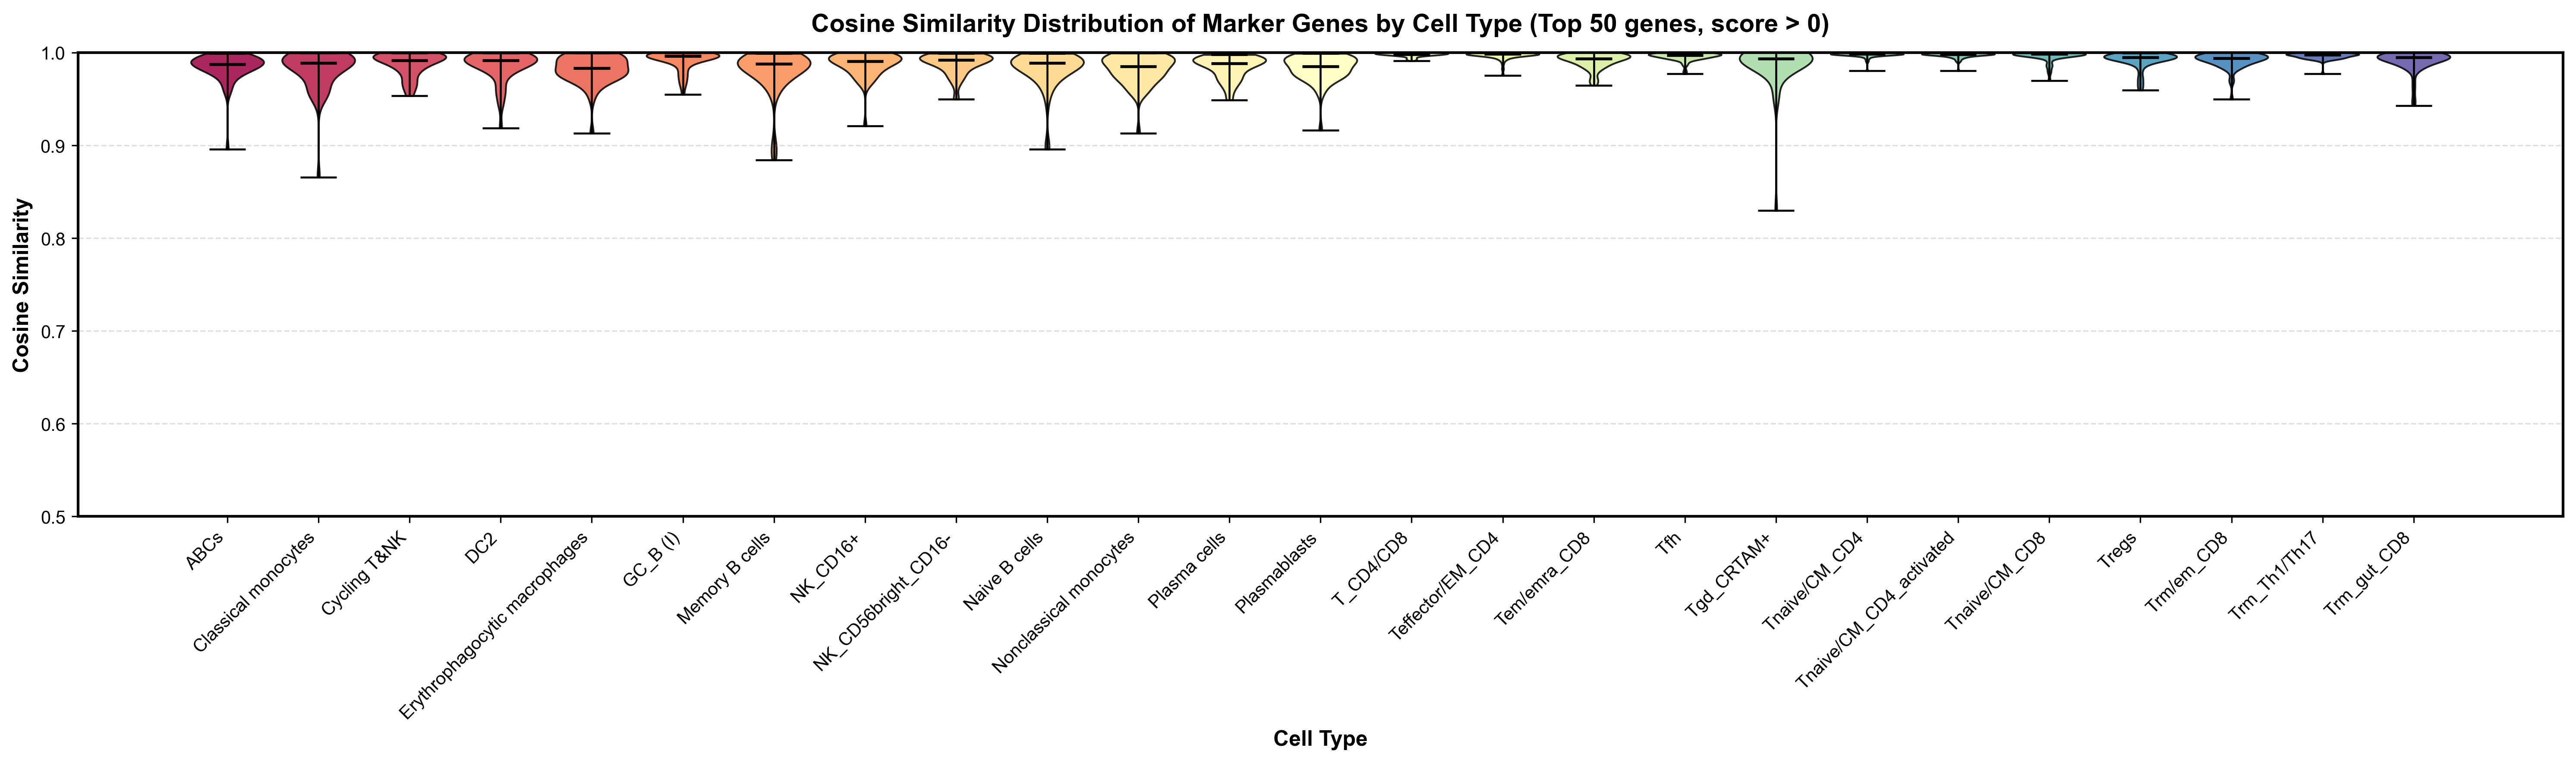

In [14]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
from scipy.spatial.distance import cosine

warnings.filterwarnings("ignore")

# =========================
# Global matplotlib settings
# =========================
plt.rcParams["font.family"] = ["Arial", "DejaVu Sans", "sans-serif"]
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.transparent"] = True


# =========================
# 0) Base path (ONLY here)
# =========================
BASE_DIR = r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_Human_sc"
INPUT_DIR = os.path.join(BASE_DIR, "input")
RESULT_DIR = os.path.join(BASE_DIR, "result_data")

H5AD_FILE = os.path.join(RESULT_DIR, "bulk_data_human_bulk_mapping.h5ad")
MARKER_FILE = os.path.join(INPUT_DIR, "marker_genes.csv")


def load_data():
    """Load h5ad and marker gene table."""
    adata = sc.read_h5ad(H5AD_FILE)

    # Expected marker file columns: cell_type, gene, score, p_value
    markers_df = pd.read_csv(MARKER_FILE)

    # Basic checks / cleanup
    required_cols = {"cell_type", "gene", "score"}
    missing = required_cols - set(markers_df.columns)
    if missing:
        raise ValueError(f"marker_genes.csv missing columns: {missing}")

    markers_df["cell_type"] = markers_df["cell_type"].astype(str)
    markers_df["gene"] = markers_df["gene"].astype(str)
    markers_df["score"] = pd.to_numeric(markers_df["score"], errors="coerce")

    return adata, markers_df


def filter_top_markers(markers_df, top_n=50):
    """Keep top-N marker genes per cell type among those with score > 0."""
    print("\n" + "=" * 80)
    print("FILTERING TOP MARKER GENES")
    print("=" * 80)

    df = markers_df.copy()

    # Filter genes with score > 0
    df = df[df["score"].notna() & (df["score"] > 0)].copy()
    print(f"After filtering score > 0: {len(df)} genes")

    filtered_markers = []
    for cell_type in df["cell_type"].unique():
        cell_markers = df[df["cell_type"] == cell_type].copy()
        cell_markers = cell_markers.sort_values("score", ascending=False).head(top_n)
        filtered_markers.append(cell_markers)
        print(f"  {cell_type}: {len(cell_markers)} marker genes (top {top_n})")

    filtered_df = pd.concat(filtered_markers, ignore_index=True) if filtered_markers else df.iloc[0:0].copy()

    print(f"\nTotal filtered marker genes: {len(filtered_df)}")
    print(f"Number of cell types: {filtered_df['cell_type'].nunique()}")

    return filtered_df


def _get_vector(mat, gene_idx):
    """Safely extract a dense 1D vector for a gene from AnnData matrix/layer."""
    col = mat[:, gene_idx]
    if hasattr(col, "toarray"):
        return col.toarray().ravel()
    return np.asarray(col).ravel()


def calculate_cosine_similarities(adata, markers_df, layer_key="mapping_ori"):
    """Compute cosine similarity per marker gene between adata.X and adata.layers[layer_key]."""
    print("\n" + "=" * 80)
    print("CALCULATING COSINE SIMILARITIES")
    print("=" * 80)

    if layer_key not in adata.layers:
        raise KeyError(f"Layer '{layer_key}' not found in adata.layers. Available: {list(adata.layers.keys())}")

    gene_names = adata.var_names.astype(str).tolist()
    gene_to_idx = {g: i for i, g in enumerate(gene_names)}

    similarity_data = []
    cell_types = markers_df["cell_type"].unique()

    for cell_type in cell_types:
        cell_markers = markers_df[markers_df["cell_type"] == cell_type].copy()
        markers = cell_markers["gene"].astype(str).tolist()

        valid_markers = [g for g in markers if g in gene_to_idx]
        if len(valid_markers) == 0:
            print(f"  {cell_type}: No valid markers found in adata.var_names")
            continue

        print(f"  {cell_type}: Processing {len(valid_markers)} valid markers...")

        for gene_name in valid_markers:
            gene_idx = gene_to_idx[gene_name]

            original_expr = _get_vector(adata.X, gene_idx)
            mapping_expr = _get_vector(adata.layers[layer_key], gene_idx)

            # Skip if NaN or all-zero vectors (cosine undefined)
            if not np.isfinite(original_expr).all() or not np.isfinite(mapping_expr).all():
                continue
            if np.all(original_expr == 0) or np.all(mapping_expr == 0):
                continue

            # Cosine similarity = 1 - cosine distance
            try:
                cos_sim = 1 - cosine(original_expr, mapping_expr)
            except Exception:
                continue

            score = float(cell_markers.loc[cell_markers["gene"].astype(str) == gene_name, "score"].iloc[0])

            similarity_data.append(
                {
                    "cell_type": cell_type,
                    "gene": gene_name,
                    "score": score,
                    "cosine_similarity": float(cos_sim),
                }
            )

    result_df = pd.DataFrame(similarity_data)
    print(f"\nTotal similarities calculated: {len(result_df)}")

    return result_df


def create_violin_plot(similarity_df, title_suffix="(Top 50 genes, score > 0)"):
    """Create a vertical violin plot. No file output; display only."""
    # Transparent background
    fig, ax = plt.subplots(figsize=(20, 6))
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    # Stable order of cell types
    cell_types = sorted(similarity_df["cell_type"].unique())

    # Prepare data per cell type
    data_for_plot = []
    for ct in cell_types:
        vals = similarity_df.loc[similarity_df["cell_type"] == ct, "cosine_similarity"].dropna().values
        data_for_plot.append(vals)

    # Colormap
    colors = plt.cm.Spectral(np.linspace(0, 1, len(cell_types))) if len(cell_types) > 0 else []

    # Violin plot: positions start at 1 (matplotlib convention)
    positions = np.arange(1, len(cell_types) + 1)

    violin_parts = ax.violinplot(
        data_for_plot,
        positions=positions,
        widths=0.8,
        showmeans=False,
        showmedians=True,
        showextrema=True,
    )

    # Style violin bodies
    for i, body in enumerate(violin_parts["bodies"]):
        body.set_facecolor(colors[i])
        body.set_alpha(0.85)
        body.set_edgecolor("black")
        body.set_linewidth(1)

    # Style internal lines (median/extrema bars)
    for k in ["cmedians", "cbars", "cmins", "cmaxes"]:
        if k in violin_parts:
            violin_parts[k].set_color("black")
            violin_parts[k].set_linewidth(1.6 if k == "cmedians" else 1.1)

    # Axis labels and title
    ax.set_xticks(positions)
    ax.set_xticklabels(cell_types, rotation=45, ha="right", fontsize=10)
    ax.set_ylabel("Cosine Similarity", fontsize=12, fontweight="bold")
    ax.set_xlabel("Cell Type", fontsize=12, fontweight="bold")
    ax.set_title(
        f"Cosine Similarity Distribution of Marker Genes by Cell Type {title_suffix}",
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    # Grid and limits
    ax.grid(True, alpha=0.25, axis="y", linestyle="--", color="gray")
    ax.set_ylim(0.5, 1.0)

    # Show full border (all spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)
        spine.set_visible(True)

    plt.tight_layout()
    return fig


def main():
    """Main entry point. Prints stats and shows plot; no files saved."""
    print("=" * 80)
    print("COSINE SIMILARITY ANALYSIS FOR TOP MARKER GENES")
    print("=" * 80)

    print("\nLoading data...")
    adata, markers_df = load_data()

    print(f"Loaded h5ad: {adata.shape[0]} samples × {adata.shape[1]} genes")
    print(f"Loaded markers: {len(markers_df)} gene-celltype pairs")
    print(f"Number of cell types: {markers_df['cell_type'].nunique()}")

    filtered_markers = filter_top_markers(markers_df, top_n=50)

    print("\nCalculating cosine similarities...")
    similarity_df = calculate_cosine_similarities(adata, filtered_markers, layer_key="mapping_ori")

    print(f"\nCalculated similarities for {len(similarity_df)} gene-celltype pairs")
    print(f"Number of cell types: {similarity_df['cell_type'].nunique()}")

    # Summary stats to console only
    print("\n" + "=" * 80)
    print("SUMMARY STATISTICS")
    print("=" * 80)
    if len(similarity_df) > 0:
        stats = (
            similarity_df.groupby("cell_type")["cosine_similarity"]
            .agg([("count", "count"), ("mean", "mean"), ("median", "median"), ("std", "std"), ("min", "min"), ("max", "max")])
            .round(3)
        )
        print(stats)
    else:
        print("No cosine similarity results were computed (check markers, genes, and layer availability).")

    print("\n" + "=" * 80)
    print("CREATING VISUALIZATION")
    print("=" * 80)

    fig = create_violin_plot(similarity_df, title_suffix="(Top 50 genes, score > 0)")
    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    main()

## Visualization Tutorial: BULK_BRCA

This visualization tutorial is for the **BULK_BRCA** package.  
All visualizations are based on **cell-type fraction tables** (CSV) for bulk BRCA samples.

CytoBulk results can be obtained in **two ways**:
1) use the provided CytoBulk output under `result_data/`, or  
2) generate your own CytoBulk predictions by running the deconvolution pipeline.

---

### 1) Download the `BULK_BRCA` package

Download the folder **`BULK_BRCA/`** from **`XXXX`**.

Folder structure (as provided):

- `BULK_BRCA/`
  - `input/`
    - `brca_sc_adata.h5ad` (single-cell reference)
    - `brca_bulk_adata.h5ad` (bulk cohort)
  - `model/` (pretrained checkpoints for reproduction, if provided)
  - `result_data/` (reference results for validation, if provided)

> Note: this tutorial assumes `input/`, `model/`, and `result_data/` are directly under `BULK_BRCA/`.

---

### 2) Files needed for visualization

#### Ground-truth (from `input/`)

Ground-truth cell-type fractions are provided in `input/` as:

- `input/BRCA_BULK_ground_data.csv`

This file is used as **ground truth** for evaluation and visualization.

#### Other methods' results (from `result_data/`)

Results from other deconvolution methods are provided under:

- `result_data/`

These outputs can be directly loaded for comparison plots (e.g., method-vs-ground-truth).

#### CytoBulk predicted fractions (two ways)

**Option 1: Use the provided CytoBulk results**  
Use the CytoBulk result CSV shipped in `result_data/`, for example:

- `result_data/BRCA_BULK_CytoBulk_data.csv`

**Option 2: Generate CytoBulk results by running the pipeline**  
Follow the run instructions in:

- `bulk_deconv_brca.md`

The generated CytoBulk prediction file will be saved under your specified output directory (`outdir`) (see `bulk_deconv_brca.md` for the exact output path and filename).

---

### 3) Summary of key fraction tables (CSV)

For visualization and comparison, you may use:

- **Ground truth:** `input/BRCA_BULK_ground_data.csv`
- **CytoBulk (provided):** `result_data/BRCA_BULK_CytoBulk_data.csv`
- **CytoBulk (generated):** output produced by `bulk_deconv_brca.md`
- **Other methods:** corresponding CSV files under `result_data/`

Loading data...
Data loading completed.
Common samples: 13
Common cell types: 29
Calculating metrics...
Metrics calculation completed.
  Pearson points: 174
  JSD points: 78
  RMSE points: 174


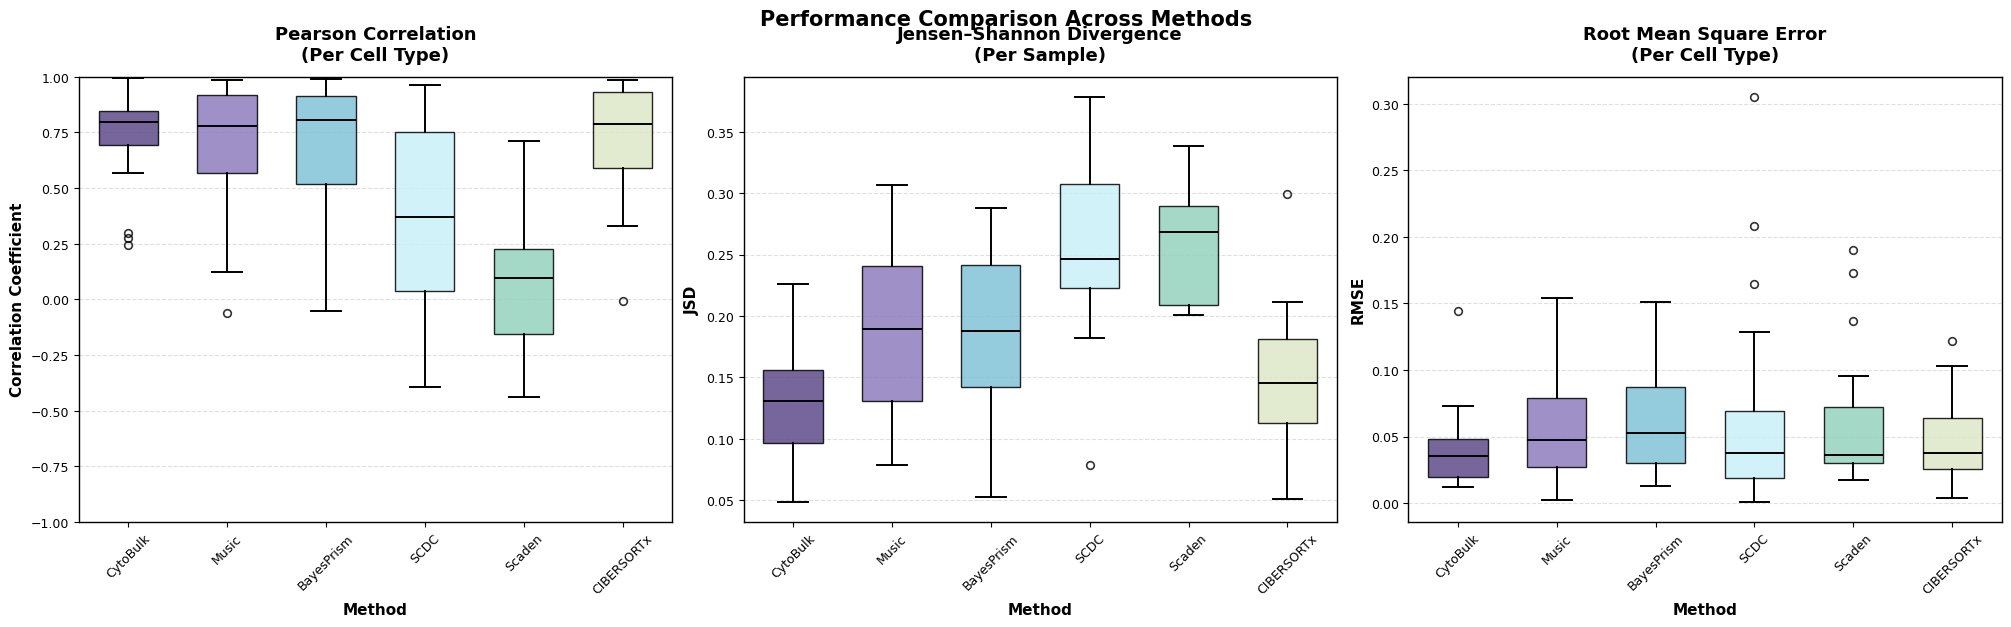

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon

# =========================
# 0) Base path (ONLY here)
# =========================
BASE_DIR = r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_BRCA"
INPUT_DIR = os.path.join(BASE_DIR, "input")
RESULT_DIR = os.path.join(BASE_DIR, "result_data")

# Input / prediction files
TRUE_FILE = os.path.join(INPUT_DIR, "BRCA_BULK_ground_data.csv")

PRED_FILES = {
    "BayesPrism":  os.path.join(RESULT_DIR, "brca_bulk_BayesPrism_data.csv"),
    "CIBERSORTx":  os.path.join(RESULT_DIR, "BRCA_BULK_CIBERSORTx_data.csv"),
    "CytoBulk":    os.path.join(RESULT_DIR, "BRCA_BULK_CytoBulk_data.csv"),
    "Music":       os.path.join(RESULT_DIR, "brca_bulk_music_data.csv"),
    "Scaden":      os.path.join(RESULT_DIR, "BRCA_BULK_scaden_data.csv"),
    "SCDC":        os.path.join(RESULT_DIR, "BRCA_BULK_SCDC_data.csv"),
}

# Plot order (controls x-axis)
methods = ["CytoBulk", "Music", "BayesPrism", "SCDC", "Scaden", "CIBERSORTx"]

# Color palette for methods
method_colors = {
    "CytoBulk": "#5f4b8b",
    "Music": "#8e7dbe",
    "BayesPrism": "#81c3d7",
    "SCDC": "#caf0f8",
    "Scaden": "#94d2bd",
    "CIBERSORTx": "#dde7c7",
}

# Global plotting style
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.style.use("default")


def jensen_shannon_divergence(p, q):
    """Compute Jensen–Shannon divergence between two non-negative vectors (auto-normalized)."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    # Clamp negatives (some methods may output tiny negatives)
    p = np.maximum(p, 0.0)
    q = np.maximum(q, 0.0)

    # Convert to probability distributions
    if p.sum() <= 0:
        p = np.ones_like(p) / len(p)
    else:
        p = p / p.sum()

    if q.sum() <= 0:
        q = np.ones_like(q) / len(q)
    else:
        q = q / q.sum()

    # scipy returns sqrt(JS), so we square it to get JS divergence
    return float(jensenshannon(p, q) ** 2)


def read_df(path):
    """Read CSV with first column as index, and coerce all values to numeric."""
    df = pd.read_csv(path, index_col=0)
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


print("Loading data...")
ground_truth_data = read_df(TRUE_FILE)

method_data = {}
for m in methods:
    method_data[m] = read_df(PRED_FILES[m])

print("Data loading completed.")

# =========================
# 1) Align samples and cell types
# =========================
common_samples = set(ground_truth_data.index)
for m in methods:
    common_samples &= set(method_data[m].index)
common_samples = sorted(common_samples)

common_cell_types = set(ground_truth_data.columns)
for m in methods:
    common_cell_types &= set(method_data[m].columns)
common_cell_types = sorted(common_cell_types)

print(f"Common samples: {len(common_samples)}")
print(f"Common cell types: {len(common_cell_types)}")

# Subset to common samples/cell types
ground_truth_data = ground_truth_data.loc[common_samples, common_cell_types]
for m in methods:
    method_data[m] = method_data[m].loc[common_samples, common_cell_types]

# =========================
# 2) Compute metrics
# =========================
print("Calculating metrics...")

pearson_rows = []
rmse_rows = []
jsd_rows = []

# Pearson and RMSE per cell type (across samples)
for cell_type in common_cell_types:
    true_values = ground_truth_data[cell_type].values

    for m in methods:
        pred_values = method_data[m][cell_type].values

        # Use only paired non-NaN entries
        valid = (~np.isnan(true_values)) & (~np.isnan(pred_values))

        # Pearson correlation
        if valid.sum() >= 2 and np.std(true_values[valid]) > 0 and np.std(pred_values[valid]) > 0:
            corr = pearsonr(true_values[valid], pred_values[valid]).statistic
        else:
            corr = np.nan
        pearson_rows.append({"Method": m, "Cell_Type": cell_type, "Value": corr})

        # RMSE
        if valid.sum() >= 1:
            rmse = sqrt(mean_squared_error(true_values[valid], pred_values[valid]))
        else:
            rmse = np.nan
        rmse_rows.append({"Method": m, "Cell_Type": cell_type, "Value": rmse})

# JSD per sample (distribution across cell types)
for sample in common_samples:
    true_dist = ground_truth_data.loc[sample, common_cell_types].values

    for m in methods:
        pred_dist = method_data[m].loc[sample, common_cell_types].values

        try:
            jsd = jensen_shannon_divergence(true_dist, pred_dist)
        except Exception:
            jsd = np.nan

        jsd_rows.append({"Method": m, "Sample": sample, "Value": jsd})

pearson_df = pd.DataFrame(pearson_rows)
rmse_df = pd.DataFrame(rmse_rows)
jsd_df = pd.DataFrame(jsd_rows)

print("Metrics calculation completed.")
print(f"  Pearson points: {len(pearson_df)}")
print(f"  JSD points: {len(jsd_df)}")
print(f"  RMSE points: {len(rmse_df)}")

# =========================
# 3) Visualization (NO saving)
# =========================
def create_boxplot(ax, data_df, title, ylabel):
    """Draw a styled boxplot for a metric DataFrame with columns: Method, Value."""
    box_data, box_labels, colors_list = [], [], []

    for m in methods:
        vals = data_df.loc[data_df["Method"] == m, "Value"].dropna().values
        box_data.append(vals)
        box_labels.append(m)
        colors_list.append(method_colors.get(m, "#cccccc"))

    bp = ax.boxplot(
        box_data,
        labels=box_labels,
        patch_artist=True,
        widths=0.6,
        showfliers=True,
    )

    # Box fill colors
    for patch, color in zip(bp["boxes"], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor("black")
        patch.set_linewidth(1)

    # Whiskers/median/caps
    for element in ["whiskers", "medians", "caps"]:
        plt.setp(bp[element], color="black", linewidth=1.4)

    # Outliers: hollow black circles
    plt.setp(
        bp["fliers"],
        marker="o",
        markerfacecolor="none",
        markersize=5.5,
        linestyle="none",
        markeredgecolor="black",
        markeredgewidth=1.2,
        alpha=0.8,
    )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")
    ax.set_xlabel("Method", fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.25, linestyle="--", color="gray")
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

    # Axis frame
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)


fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

create_boxplot(
    axes[0],
    pearson_df,
    "Pearson Correlation\n(Per Cell Type)",
    "Correlation Coefficient",
)
axes[0].set_ylim(-1.0, 1.0)

create_boxplot(
    axes[1],
    jsd_df,
    "Jensen–Shannon Divergence\n(Per Sample)",
    "JSD",
)

create_boxplot(
    axes[2],
    rmse_df,
    "Root Mean Square Error\n(Per Cell Type)",
    "RMSE",
)

fig.suptitle("Performance Comparison Across Methods", fontsize=15, fontweight="bold", y=1.02)

# Show only; do not save any files
plt.show()

### 4) Bulk mapping visualization (BRCA case)

For **bulk mapping** visualization in the **BULK_BRCA** case, you need **two inputs**:

1) **Marker genes list** (from `input/`):
- `input/marker_gene.txt`

2) **Bulk mapping result** (from `result_data/`):
- `result_data/bulk_data_brca_bulk_mapping.h5ad`

These two files (`marker_gene.txt` + mapping `.h5ad`) are the required inputs for bulk-mapping visualizations (e.g., marker-based highlighting/scoring on the mapped space and mapping-based annotation plots).

                  cell_type  n   mean  median    std    min    max
           Endothelial RGS5 50 0.9563  0.9684 0.0375 0.7754 0.9907
          Endothelial ACKR1 50 0.9544  0.9638 0.0356 0.7754 0.9907
         CAFs MSC iCAF-like 50 0.9505  0.9539 0.0247 0.9041 0.9907
         Endothelial CXCL12 50 0.9503  0.9631 0.0400 0.7754 0.9907
            CAFs myCAF-like 50 0.9500  0.9554 0.0276 0.8479 0.9907
               PVL Immature 50 0.9475  0.9584 0.0402 0.7745 0.9907
         PVL Differentiated 50 0.9469  0.9579 0.0386 0.7745 0.9907
            Cycling T-cells 50 0.9467  0.9556 0.0273 0.8672 0.9850
                   Monocyte 50 0.9414  0.9507 0.0292 0.8624 0.9863
             Cancer Cycling 50 0.9373  0.9532 0.0545 0.6251 0.9833
                Cycling PVL 50 0.9372  0.9555 0.0548 0.7536 0.9907
             Mature Luminal 50 0.9359  0.9475 0.0415 0.7670 0.9857
Endothelial Lymphatic LYVE1 50 0.9352  0.9585 0.0536 0.7754 0.9846
            Cycling_Myeloid 50 0.9327  0.9460 0.0505 0.6805 0.

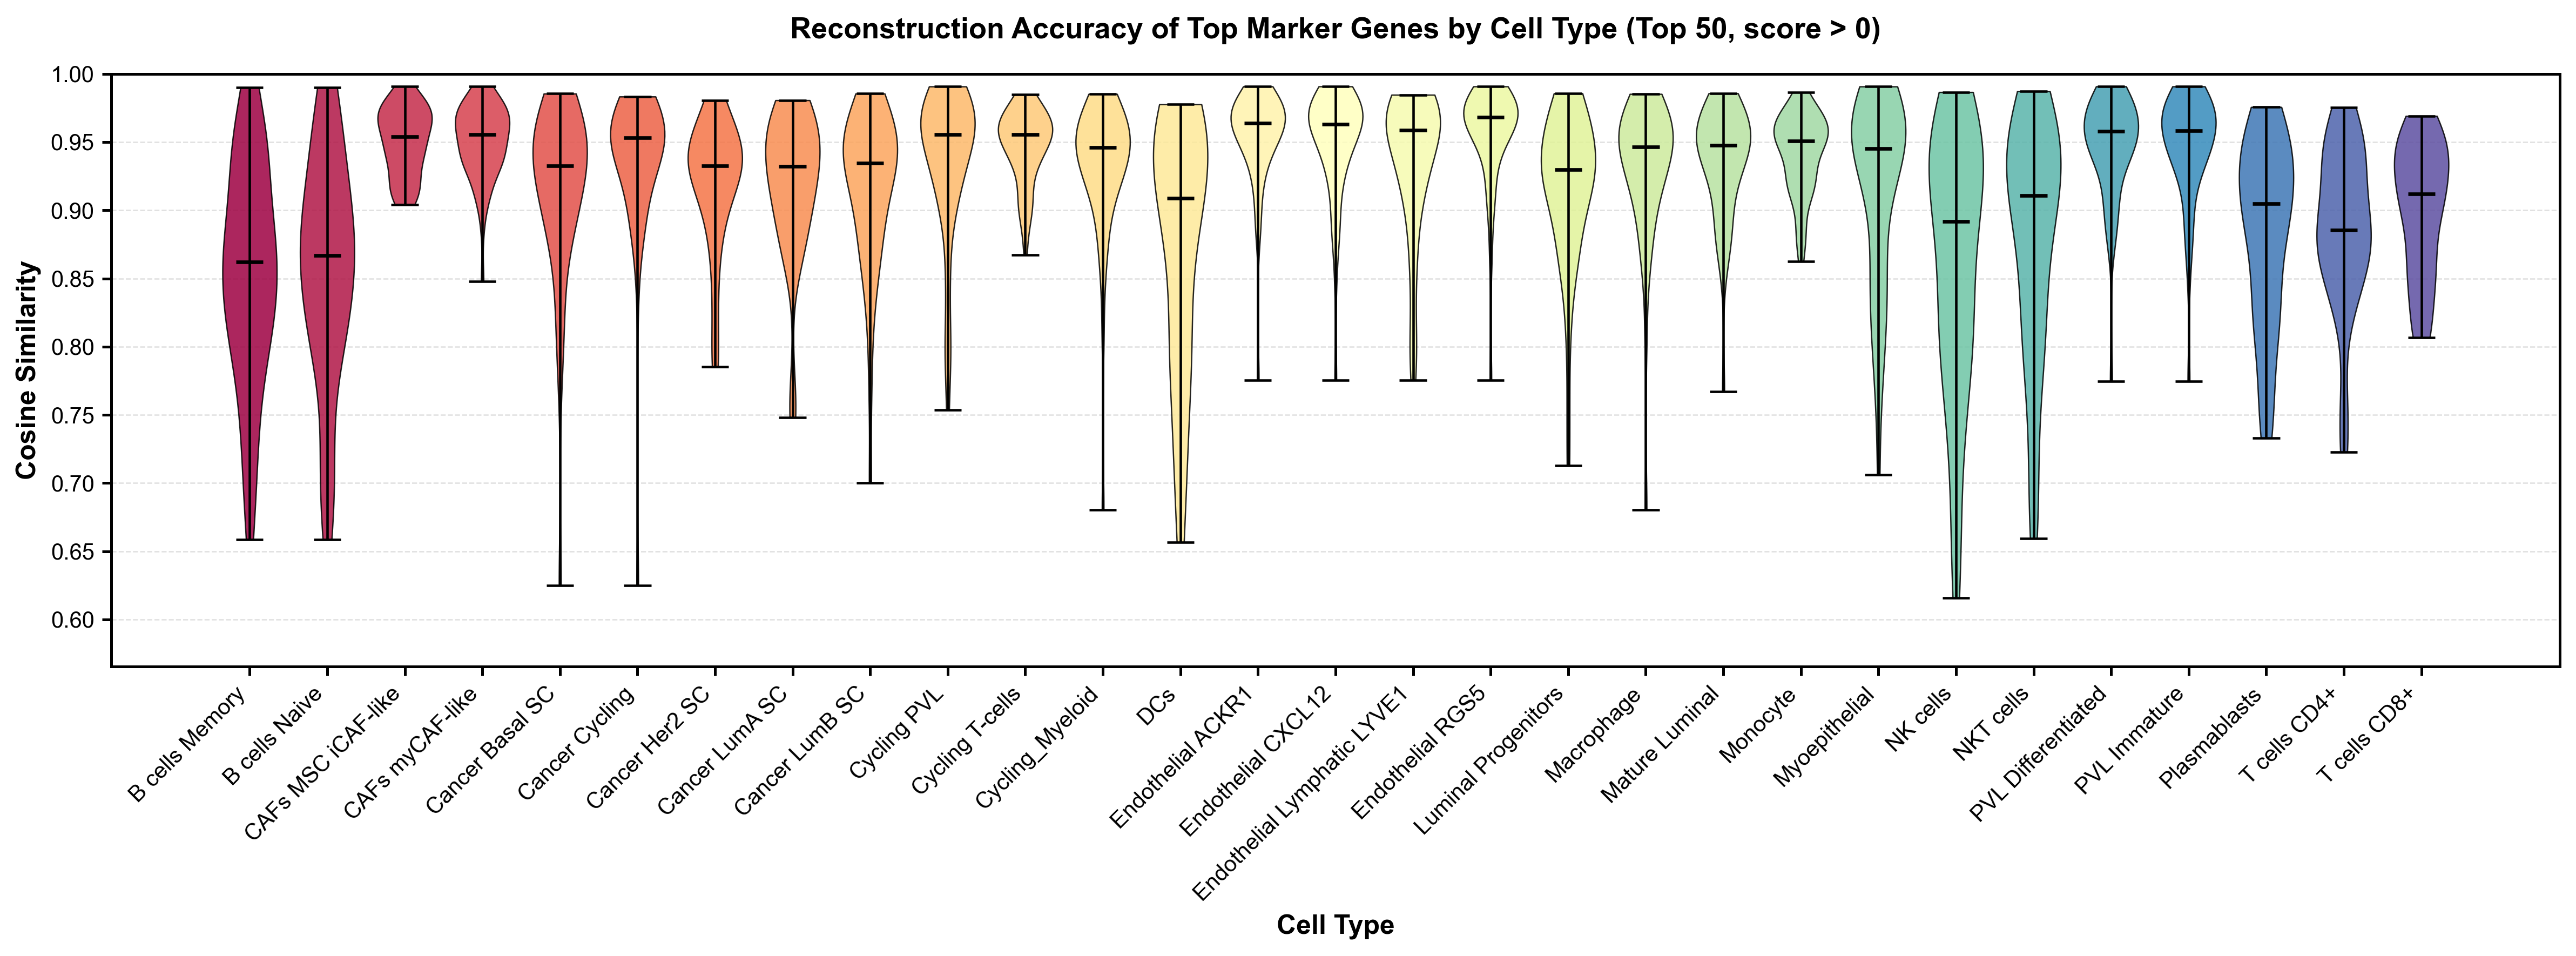

In [18]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
from scipy.spatial.distance import cosine

warnings.filterwarnings("ignore")

# =========================
# Global matplotlib settings
# =========================
plt.rcParams["font.family"] = ["Arial", "DejaVu Sans", "sans-serif"]
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.transparent"] = True

# =========================
# 0) Base path (ONLY here)
# =========================
BASE_DIR = r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_BRCA"
INPUT_DIR = os.path.join(BASE_DIR, "input")
RESULT_DIR = os.path.join(BASE_DIR, "result_data")

H5AD_FILE = os.path.join(RESULT_DIR, "bulk_data_brca_bulk_mapping.h5ad")
MARKER_FILE = os.path.join(INPUT_DIR, "marker_gene.txt")


def load_data():
    adata = sc.read_h5ad(H5AD_FILE)
    markers_df = pd.read_csv(MARKER_FILE, sep="\t")

    required_cols = {"cell_type", "gene", "score"}
    missing = required_cols - set(markers_df.columns)
    if missing:
        raise ValueError(f"marker_gene.txt missing columns: {missing}")

    markers_df["cell_type"] = markers_df["cell_type"].astype(str)
    markers_df["gene"] = markers_df["gene"].astype(str)
    markers_df["score"] = pd.to_numeric(markers_df["score"], errors="coerce")

    # optional pvalue normalization
    if "pvalue" in markers_df.columns:
        markers_df["pvalue"] = pd.to_numeric(markers_df["pvalue"], errors="coerce")
    elif "p_value" in markers_df.columns:
        markers_df = markers_df.rename(columns={"p_value": "pvalue"})
        markers_df["pvalue"] = pd.to_numeric(markers_df["pvalue"], errors="coerce")
    else:
        markers_df["pvalue"] = np.nan

    return adata, markers_df


def filter_marker_genes_by_celltype(markers_df, adata, top_n=50):
    """Per cell type: intersect genes, score>0, take top_n by score. No prints."""
    available_genes = set(adata.var_names.astype(str).tolist())

    out = []
    for cell_type in markers_df["cell_type"].unique():
        cell_markers = markers_df[markers_df["cell_type"] == cell_type].copy()
        cell_markers = cell_markers[cell_markers["gene"].isin(available_genes)].copy()
        cell_markers = cell_markers[cell_markers["score"].notna() & (cell_markers["score"] > 0)].copy()
        top_markers = cell_markers.sort_values("score", ascending=False).head(top_n)
        if len(top_markers) > 0:
            out.append(top_markers)

    return pd.concat(out, ignore_index=True) if out else markers_df.iloc[0:0].copy()


def _get_vector(mat, gene_idx):
    col = mat[:, gene_idx]
    if hasattr(col, "toarray"):
        return col.toarray().ravel()
    return np.asarray(col).ravel()


def calculate_cosine_similarities(adata, filtered_markers, layer_key="mapping_ori"):
    """No prints."""
    if layer_key not in adata.layers:
        raise KeyError(f"Layer '{layer_key}' not found. Available: {list(adata.layers.keys())}")

    gene_names = adata.var_names.astype(str).tolist()
    gene_to_idx = {g: i for i, g in enumerate(gene_names)}

    rows = []
    for _, r in filtered_markers.iterrows():
        gene = str(r["gene"])
        cell_type = str(r["cell_type"])
        score = float(r["score"]) if pd.notna(r["score"]) else np.nan

        gene_idx = gene_to_idx.get(gene)
        if gene_idx is None:
            continue

        x = _get_vector(adata.X, gene_idx)
        y = _get_vector(adata.layers[layer_key], gene_idx)

        if not np.isfinite(x).all() or not np.isfinite(y).all():
            continue

        if np.all(x == 0) or np.all(y == 0):
            cos_sim = 0.0
        else:
            try:
                cos_sim = 1 - cosine(x, y)
            except Exception:
                continue

        rows.append(
            {"cell_type": cell_type, "gene": gene, "cosine_similarity": float(cos_sim), "score": score}
        )

    return pd.DataFrame(rows)


def print_celltype_similarity_summary(similarity_df):
    """
    ONLY output: per-cell-type similarity summary.
    """
    if similarity_df is None or len(similarity_df) == 0:
        print("No cosine similarity results.")
        return

    summary = (
        similarity_df.groupby("cell_type")["cosine_similarity"]
        .agg(n="count", mean="mean", median="median", std="std", min="min", max="max")
        .reset_index()
    )

    # nicer formatting
    summary = summary.sort_values("mean", ascending=False)
    num_cols = ["mean", "median", "std", "min", "max"]
    summary[num_cols] = summary[num_cols].round(4)

    print(summary.to_string(index=False))


def create_violin_plot(similarity_df, top_n=50):
    fig, ax = plt.subplots(figsize=(16, 6))
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    cell_types = sorted(similarity_df["cell_type"].unique())
    colors = plt.cm.Spectral(np.linspace(0, 1, len(cell_types))) if len(cell_types) else []

    data_for_plot, cell_types_with_data, colors_with_data = [], [], []
    for i, ct in enumerate(cell_types):
        vals = similarity_df.loc[similarity_df["cell_type"] == ct, "cosine_similarity"].dropna().values
        if len(vals) > 0:
            data_for_plot.append(vals)
            cell_types_with_data.append(ct)
            colors_with_data.append(colors[i])

    positions = np.arange(1, len(cell_types_with_data) + 1)

    violin_parts = ax.violinplot(
        data_for_plot,
        positions=positions,
        widths=0.7,
        showmeans=False,
        showmedians=True,
        showextrema=True,
    )

    for i, body in enumerate(violin_parts["bodies"]):
        body.set_facecolor(colors_with_data[i])
        body.set_alpha(0.85)
        body.set_edgecolor("black")
        body.set_linewidth(0.6)

    for k in ["cmedians", "cbars", "cmins", "cmaxes"]:
        if k in violin_parts:
            violin_parts[k].set_color("black")
            violin_parts[k].set_linewidth(1.6 if k == "cmedians" else 1.1)

    ax.set_xticks(positions)
    ax.set_xticklabels(cell_types_with_data, rotation=45, ha="right", fontsize=10)
    ax.set_xlabel("Cell Type", fontsize=12, fontweight="bold")
    ax.set_ylabel("Cosine Similarity", fontsize=12, fontweight="bold")
    ax.set_title(
        f"Reconstruction Accuracy of Top Marker Genes by Cell Type (Top {top_n}, score > 0)",
        fontsize=13,
        fontweight="bold",
        pad=16,
    )

    if len(similarity_df) and similarity_df["cosine_similarity"].notna().any():
        y_min = max(0.0, float(similarity_df["cosine_similarity"].min()) - 0.05)
        y_max = min(1.0, float(similarity_df["cosine_similarity"].max()) + 0.05)
        if y_max <= y_min:
            y_min, y_max = 0.0, 1.0
    else:
        y_min, y_max = 0.0, 1.0
    ax.set_ylim(y_min, y_max)

    ax.grid(True, alpha=0.25, axis="y", linestyle="--", linewidth=0.6, color="gray")
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.2)
        spine.set_visible(True)

    ax.tick_params(axis="both", which="major", labelsize=10, color="black", width=1.2, length=4)

    plt.tight_layout()
    return fig


def main():
    adata, markers_df = load_data()

    top_n = 50
    filtered_markers = filter_marker_genes_by_celltype(markers_df, adata, top_n=top_n)
    if len(filtered_markers) == 0:
        print("No valid marker genes found after filtering.")
        return

    similarity_df = calculate_cosine_similarities(adata, filtered_markers, layer_key="mapping_ori")
    if len(similarity_df) == 0:
        print("No valid genes found for cosine similarity analysis.")
        return

    # ONLY output per-cell-type similarity info
    print_celltype_similarity_summary(similarity_df)

    # plot (no extra prints)
    fig = create_violin_plot(similarity_df, top_n=top_n)
    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    main()

## Visualization Tutorial: BULK_TCGA

The input package `BULK_TCGA/` contains **three TCGA tasks** (each task = one bulk cohort + one single-cell reference):

- `TCGA_HNSC`
- `TCGA_LIHC`
- `TCGA_SKCM`

All visualizations are based on **visualization-ready result files** (e.g., predicted cell-type fraction tables) for each task.  
These visualization files can be obtained in **two ways**:

1) **Use the provided outputs** shipped with the downloaded package under each task’s `result_data/`, or  
2) **Reproduce (regenerate) the outputs** by running the TCGA pipeline following `bulk_deconv_TCGA.md`.

---

## 1) Download the `BULK_TCGA` package

Download the folder **`BULK_TCGA/`** from **`XXXX`**.

Folder structure (as provided):

- `BULK_TCGA/`
  - `TCGA_HNSC/`
    - `input/`
      - `HNSC_GSE103322_adata.h5ad` (single-cell reference)
      - `TCGA_HNSC_adata.h5ad` (bulk)
    - `model/` (pretrained checkpoints for reproduction)
    - `result_data/` (**provided visualization-ready outputs**)
  - `TCGA_LIHC/`
    - `input/`
      - `GSE125449.h5ad` (single-cell reference)
      - `RNA_TCGA_LIHC.h5ad` (bulk)
    - `model/`
    - `result_data/` (**provided visualization-ready outputs**)
  - `TCGA_SKCM/`
    - `input/`
      - `GSE115978.h5ad` (single-cell reference)
      - `RNA_TCGA_SKCM.h5ad` (bulk)
    - `model/`
    - `result_data/` (**provided visualization-ready outputs**)

> Note: dataset names in this tutorial **must match** the folder names above:  
> `TCGA_HNSC`, `TCGA_LIHC`, `TCGA_SKCM`.

---

## 2) Visualization files: two ways to obtain

### Option 1: Use the provided visualization outputs (`result_data/`)

After downloading `BULK_TCGA/`, each task folder contains a `result_data/` directory with ready-to-plot outputs.

Example (LIHC):

- `BULK_TCGA/TCGA_LIHC/result_data/TCGA_LIHC_prediction_frac.csv`

You can directly use these `result_data/` files as inputs for your visualization scripts (stacked barplots, heatmaps, cohort summaries, etc.).

### Option 2: Reproduce the visualization outputs (run the pipeline)

If you want to regenerate the same type of outputs (instead of using the provided `result_data/`), run the reproduction pipeline described in:

- `bulk_deconv_TCGA.md`

This will generate visualization-ready files (e.g., `*_prediction_frac.csv`) under your specified output directory (`outdir`).  
Refer to `bulk_deconv_TCGA.md` for the exact output paths and filenames.

---



**For the following visualizations, we use **TCGA_LIHC** as an example and take `BULK_TCGA/TCGA_LIHC/result_data/TCGA_LIHC_prediction_frac.csv` as the input (or reproduce the same output by running `bulk_deconv_TCGA.md`).**

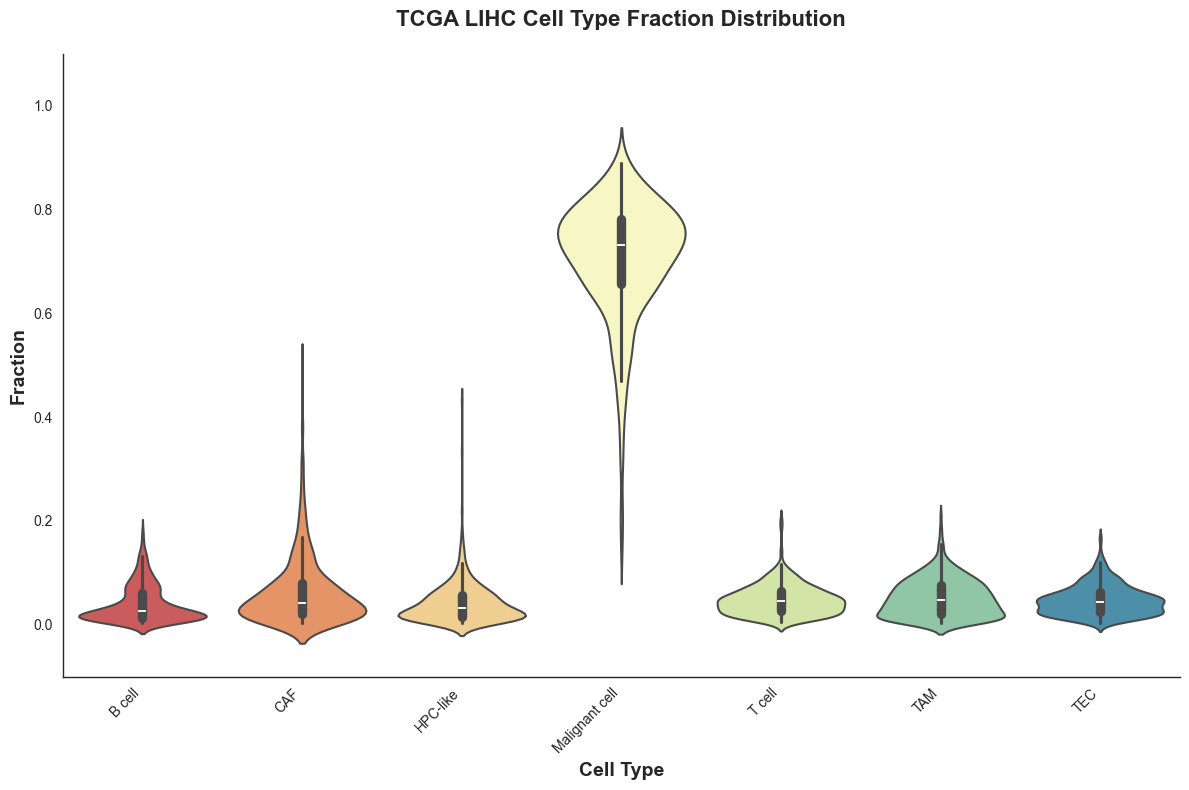

In [21]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read data
file_path = r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_TCGA\TCGA_LIHC\result_data\TCGA_LIHC_prediction_frac.csv"
df = pd.read_csv(file_path, index_col=0)

# Convert data from wide format to long format for violin plot
df_melted = df.reset_index().melt(
    id_vars=['index'],
    var_name='Cell_Type',
    value_name='Fraction'
)
df_melted = df_melted.rename(columns={'index': 'Sample_ID'})

# Set figure style - remove background
plt.style.use('default')
sns.set_style("white")

# Create violin plot
fig, ax = plt.subplots(figsize=(12, 8))

# Build color palette using Spectral colormap
n_colors = len(df.columns)
colors = sns.color_palette("Spectral", n_colors)

# Draw violin plot with different colors for each violin
sns.violinplot(
    data=df_melted,
    x='Cell_Type',
    y='Fraction',
    ax=ax,
    inner='box',  # Show boxplot inside violin
    linewidth=1.5,
    palette=colors  # Use Spectral palette
)

# Remove background and borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Beautify the plot
ax.set_title('TCGA LIHC Cell Type Fraction Distribution',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Cell Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Fraction', fontsize=14, fontweight='bold')

# Rotate x-axis labels to avoid overlap
plt.xticks(rotation=45, ha='right')

# Adjust y-axis range
ax.set_ylim(-0.1, 1.1)

# Set white background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Adjust layout
plt.tight_layout()

# Show directly
plt.show()
plt.close()

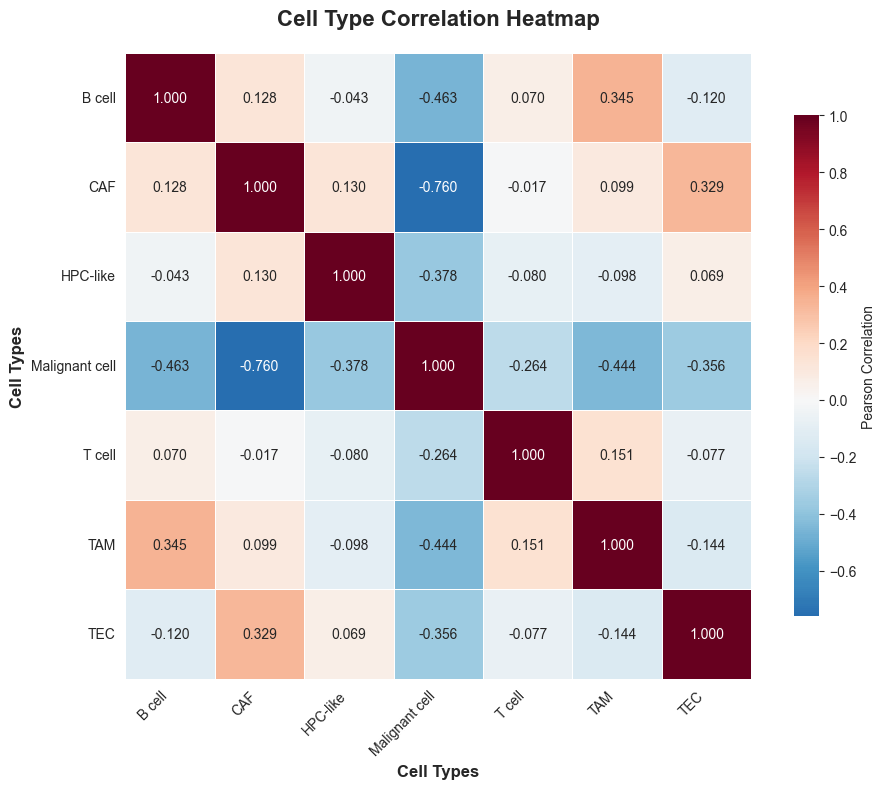

In [22]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_celltype_correlation_heatmap(file_path, figsize=(10, 8), cmap='RdBu_r',
                                     annot=True, fmt='.3f'):
    # Read data
    df = pd.read_csv(file_path, index_col=0)

    # Calculate Pearson correlation matrix
    corr_matrix = df.corr(method='pearson')

    # Create heatmap (show only)
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr_matrix,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"}
    )

    plt.title('Cell Type Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Cell Types', fontsize=12, fontweight='bold')
    plt.ylabel('Cell Types', fontsize=12, fontweight='bold')

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()
    plt.close()

    return corr_matrix


if __name__ == "__main__":
    file_path = r"C:\Users\wangxueying\project\CytoBulk\cytobulk_zenodo_data\BULK_TCGA\TCGA_LIHC\result_data\TCGA_LIHC_prediction_frac.csv"
    plot_celltype_correlation_heatmap(
        file_path,
        figsize=(10, 8),
        cmap='RdBu_r'
    )